# Creates land flux graphs
First are figures used in the manuscript (main and supplemental text), then figures not used in the manuscript but that we might want to use elsewhere. 

From Oscar Senar via Slack 2026-06-23, then adapted by David Gibbs using Claude session 'LULUCF figure updates'

In [1]:
import pandas as pd
import yaml
try:
    import geodatasets  # unused by figures; optional
except ModuleNotFoundError:
    geodatasets = None
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
try:
    import pygwalker as pyg  # unused by figures; optional
except ModuleNotFoundError:
    pyg = None
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib as _mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import glob
import gc
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm import tqdm

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu
from src.utilities.create_cluster import create_cluster as cc_create_cluster

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

## Input table paths and general styling

In [3]:
# LULUCF outputs (local copy of the parquet lives in ./data)
LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')
LULUCF_zonal_stats_folder

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1')

In [14]:
# Folder where figures go
LULUCF_zonal_stats_folder_figures = Path(f'{LULUCF_zonal_stats_folder}/figures/')
os.makedirs(LULUCF_zonal_stats_folder_figures, exist_ok=True)
LULUCF_zonal_stats_folder_figures

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1/figures')

In [4]:
# Reads wide LULUCF table
LULUCF_for_figures = pd.read_parquet(
    LULUCF_zonal_stats_folder / 'LULUCF__v1_0_0__for_figures__wide__20260617.parquet'
)

In [5]:
# Column names in LULUCF_wide
COL_MINERAL_SOIL_NET = 'SOC_net__mineral_soil_extent__0_30cm_MgCO2_yr'
COL_MINERAL_SOIL_LOSS = 'SOC_loss__mineral_soil_extent__0_30cm_MgCO2_yr'
COL_MINERAL_SOIL_GAIN = 'SOC_gain__mineral_soil_extent__0_30cm_MgCO2_yr'
COL_ORGANIC_SOIL = 'org_soil_emis__all_gases__MgCO2e_yr'   # total (renamed in 20260617 data)
# Organic soil breakdown (sum to COL_ORGANIC_SOIL)
COL_ORGANIC_SOIL_DRAINED        = 'org_soil_drained_only__all_gases__MgCO2e_yr'
COL_ORGANIC_SOIL_BURNED         = 'org_soil_burned_only__all_gases__MgCO2e_yr'
COL_ORGANIC_SOIL_DRAINED_BURNED = 'org_soil_drained_burned__all_gases__MgCO2e_yr'
COL_VEG_EMIS     = 'veg__gross_emissions__all_C_pools__all_gases__MgCO2e_yr'
COL_VEG_REMOV    = 'veg__gross_removals__all_C_pools__MgCO2_yr'
COL_LULUCF_NET   = 'LULUCF_net_flux__MgCO2e_yr'

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# Shared figure-styling helpers (local restyle; applied to all charts)
#   despine               - remove the box, keep the x & y axes
#   style_value_axis      - symmetric (or 0-anchored) limits, snapped to grid lines
#   horizontal_axis_label - axis title horizontal, top-left (not rotated)
#   grouped_legend_top    - legend above the axes/figure, one bold group per line
# ════════════════════════════════════════════════════════════════════════════

def despine(ax):
    """Remove the box: drop top + right spines, keep the x and y axes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _nice_step(span, target_ticks=8):
    if span <= 0:
        return 1.0
    raw = span / target_ticks
    mag = 10.0 ** np.floor(np.log10(raw))
    for m in (1, 2, 2.5, 5, 10):
        if raw <= m * mag:
            return m * mag
    return 10 * mag


def style_value_axis(ax, dmin, dmax, which="y", step=None, target_ticks=8, pad_frac=0.05):
    """Limits on the value axis ('y' or 'x'): symmetric when data crosses zero,
    else anchored at 0 — and snapped to whole multiples of the tick step so the
    axis begins and ends exactly on a grid line."""
    if dmin < 0 < dmax:
        M = max(abs(dmin), abs(dmax)) * (1 + pad_frac)
        if step is None:
            step = _nice_step(2 * M, target_ticks)
        M = np.ceil(M / step) * step
        lo, hi = -M, M
    elif dmax <= 0:
        m = abs(dmin) * (1 + pad_frac)
        if step is None:
            step = _nice_step(m, target_ticks)
        lo, hi = -np.ceil(m / step) * step, 0.0
    else:
        m = dmax * (1 + pad_frac)
        if step is None:
            step = _nice_step(m, target_ticks)
        lo, hi = 0.0, np.ceil(m / step) * step
    if which == "y":
        ax.yaxis.set_major_locator(MultipleLocator(step))
        ax.set_ylim(lo, hi)
        ax.grid(visible=True, axis="y", color="0.85", linewidth=0.4)
    else:
        ax.xaxis.set_major_locator(MultipleLocator(step))
        ax.set_xlim(lo, hi)
        ax.grid(visible=True, axis="x", color="0.85", linewidth=0.4)
    ax.set_axisbelow(True)
    return lo, hi, step


def horizontal_axis_label(ax, text, which="y", fontsize=5, pad=4, x=0.0):
    """Axis title placed horizontally at the top-left, above the axis (not rotated).
    `x` is the axes-fraction x of the label's left edge (use left_align_x to line it
    up with the tick numbers rather than the axis line)."""
    if which == "y":
        ax.set_ylabel("")
    else:
        ax.set_xlabel("")
    ax.annotate(text, xy=(x, 1), xycoords="axes fraction",
                xytext=(0, pad), textcoords="offset points",
                ha="left", va="bottom", fontsize=fontsize)


def grouped_legend_top(ax, groups, x=0.0, base_pt=12, line_pt=7, fontsize=5,
                       single_line=False, align_text_left=False):
    """Legend above the axes; auto-wraps onto extra rows whenever a row would exceed the figure width."""
    from matplotlib.legend import Legend
    from matplotlib.transforms import offset_copy
    fig = ax.figure
    fig.canvas.draw()
    rr = fig.canvas.get_renderer()
    figw = fig.get_window_extent().width

    def _mk(handles, labels, y_pt, bold_idx):
        tr = offset_copy(ax.transAxes, fig=fig, x=0, y=y_pt, units="points")
        leg = Legend(ax, handles, labels, loc="lower left", bbox_to_anchor=(x, 1.0),
                     bbox_transform=tr, ncol=len(handles), frameon=False, handletextpad=0.4,
                     columnspacing=1.3, fontsize=fontsize, borderaxespad=0, borderpad=0)
        for bi in bold_idx:
            leg.get_texts()[bi].set_fontweight("bold")
        leg.set_clip_on(False)
        ax.add_artist(leg)
        # Align the row's leftmost VISIBLE element to x: when the row begins with a
        # group header (invisible handle) align by its text; otherwise the first
        # element is a real swatch, so leave the handle at x (don't shift, else the
        # swatch protrudes left of x and the row appears to start further left).
        if align_text_left and (0 in bold_idx):
            fig.canvas.draw()
            x0 = ax.transAxes.inverted().transform((leg.get_texts()[0].get_window_extent(rr).x0, 0))[0]
            leg.set_bbox_to_anchor((x + (x - x0), 1.0), transform=tr)
        return leg

    def entries_of(grp_list):
        es = []
        for gname, items in grp_list:
            es.append((Line2D([], [], linestyle="", marker=""), gname, True))
            for h, lab in items:
                es.append((h, lab, False))
        return es

    def build(es, y):
        return _mk([e[0] for e in es], [e[1] for e in es], y, [i for i, e in enumerate(es) if e[2]])

    def pack(es):
        rows, cur = [], []
        for e in es:
            leg = build(cur + [e], base_pt)
            fig.canvas.draw()
            over = leg.get_window_extent(rr).x1 > figw - 2
            leg.remove()
            if cur and over and not all(t[2] for t in cur):
                # never orphan a group header at the end of a row: pull any
                # trailing header(s) down to start the next row with e, so the
                # break falls BEFORE the group name, not after it
                trail = []
                while cur and cur[-1][2]:
                    trail.insert(0, cur.pop())
                rows.append(cur); cur = trail + [e]
            else:
                cur = cur + [e]
        if cur:
            rows.append(cur)
        return rows

    if single_line:
        rows = pack(entries_of(groups))
    else:
        rows = []
        for grp in groups:
            rows += pack(entries_of([grp]))
    rh = max(line_pt, fontsize * 1.9)
    n = len(rows)
    for k, row in enumerate(rows):
        build(row, base_pt + (n - 1 - k) * rh)


def legend_top(ax, items, x=0.0, base_pt=12, fontsize=5, align_text_left=False,
               columnspacing=1.8):
    """Simple one-row legend above the axes (no bold group headers).
    items = [(handle, label), ...]."""
    from matplotlib.legend import Legend
    from matplotlib.transforms import offset_copy
    fig = ax.figure
    tr = offset_copy(ax.transAxes, fig=fig, x=0, y=base_pt, units="points")
    leg = Legend(ax, [h for h, _ in items], [l for _, l in items],
                 loc="lower left", bbox_to_anchor=(x, 1.0), bbox_transform=tr,
                 ncol=len(items), frameon=False, handletextpad=0.5,
                 columnspacing=columnspacing, fontsize=fontsize,
                 borderaxespad=0, borderpad=0)
    leg.set_clip_on(False)
    ax.add_artist(leg)
    if align_text_left:
        fig.canvas.draw()
        rr = fig.canvas.get_renderer()
        x0 = ax.transAxes.inverted().transform(
            (leg.get_texts()[0].get_window_extent(rr).x0, 0))[0]
        leg.set_bbox_to_anchor((x + (x - x0), 1.0), transform=tr)
    return leg


def left_align_x(ax):
    """Axes-fraction x of the left edge of the leftmost (widest) y tick label.
    Use to line the y-title and legend up with the tick numbers, not the axis line.
    Call after limits/ticks are set; it forces a draw to measure label extents."""
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    xs = [t.get_window_extent(r).x0 for t in ax.get_yticklabels() if t.get_text()]
    if not xs:
        return 0.0
    return float(ax.transAxes.inverted().transform((min(xs), 0))[0])


_WORLD_ROB = None

def load_world_robinson():
    """Natural Earth country polygons, loaded once and reprojected to Robinson."""
    global _WORLD_ROB
    if _WORLD_ROB is None:
        import geopandas as gpd
        import os as _os
        _ne = "data/ne_110m_admin_0_countries.zip"
        _src = _ne if _os.path.exists(_ne) else "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
        w = gpd.read_file(_src).rename(columns={"ISO_A3_EH": "iso_a3"})
        w = w[w["iso_a3"] != "ATA"].copy()
        _WORLD_ROB = w.to_crs("ESRI:54030")
    return _WORLD_ROB


def region_inset_map(ax, world, in_region, frac_w=0.40, pad=0.02, lift=0.02,
                     base_color="0.86", hi_color="0.55", zorder=0.7):
    """Robinson locator map in the bottom-right of ax, drawn ON the main axes so it
    layers between the grid (behind) and the bars (in front). All countries base_color;
    countries where in_region is True hi_color; no borders."""
    fig = ax.figure
    fig.canvas.draw()
    bb = ax.get_window_extent()
    minx, miny, maxx, maxy = world.total_bounds
    aspect = (maxx - minx) / (maxy - miny)
    w_frac = frac_w
    h_frac = (frac_w * bb.width / aspect) / bb.height
    x0 = 1 - w_frac - pad
    y0 = pad + lift
    sx = w_frac / (maxx - minx)
    sy = h_frac / (maxy - miny)
    mat = [sx, 0, 0, sy, x0 - minx * sx, y0 - miny * sy]   # Robinson -> axes fraction
    wt = world.copy()
    wt["geometry"] = world.geometry.affine_transform(mat)
    wt.plot(ax=ax, color=base_color, linewidth=0, transform=ax.transAxes, zorder=zorder, aspect="auto")
    sub = wt[in_region]
    if len(sub):
        sub.plot(ax=ax, color=hi_color, linewidth=0, transform=ax.transAxes, zorder=zorder + 0.01, aspect="auto")
    ax.set_aspect("auto")   # geopandas forces 'equal'; restore so the bar axes isn't squished
    ax.set_axisbelow(True)
    for gl in ax.get_xgridlines():
        gl.set_zorder(zorder - 0.05)   # gridlines behind the map
    return wt


def step_net_line(ax, x, y, color="black", lw=0.7, ms=2, mew=0, z=5):
    """Net flux as a plain line through the yearly values, with a dot at each
    point (no marker outline)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ax.plot(x, y, linewidth=lw, color=color, zorder=z)
    ax.plot(x, y, linestyle="none", marker="o", markersize=ms,
            markerfacecolor=color, markeredgecolor="none", markeredgewidth=mew, zorder=z + 1)


# ── Nature export style (Helvetica, 5 pt, 300 dpi, 180 mm wide) ──
import os as _os
from matplotlib import font_manager as _fm
try:
    from fontTools.ttLib import TTCollection as _TTC
    _hb = _os.path.abspath("fonts/Helvetica-Bold.ttf")
    if not _os.path.exists(_hb):
        _os.makedirs("fonts", exist_ok=True)
        _TTC("/System/Library/Fonts/Helvetica.ttc").fonts[1].save(_hb)
    _fm.fontManager.addfont(_hb)
except Exception:
    pass
_mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 5, "axes.titlesize": 5, "axes.labelsize": 5,
    "xtick.labelsize": 5, "ytick.labelsize": 5, "legend.fontsize": 5, "legend.title_fontsize": 5,
    "savefig.dpi": 300, "axes.linewidth": 0.5, "lines.linewidth": 0.7, "lines.markersize": 2,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5, "patch.linewidth": 0.3,
    "grid.linewidth": 0.4, "hatch.linewidth": 0.4,
})
FIG_W_IN = 180 / 25.4
def panel_label(ax, s, x=-0.06, y=1.04):
    ax.text(x, y, s, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom", ha="left")


## Figure creation

### Figures for manuscript

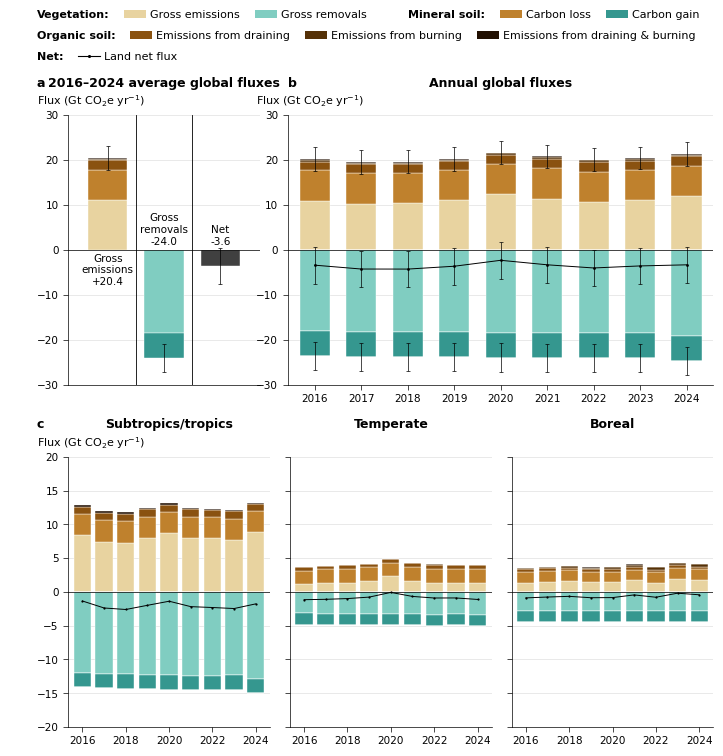

In [15]:
### Global LULUCF: avg-annual summary (a) + 2016-2024 timeseries (b); climate-domain timeseries (c).
### Panel a = cell-23-style 3-bar summary built from cell-12 components (combined to match the legend).

desired_bar_order  = [COL_ORGANIC_SOIL_DRAINED_BURNED, COL_ORGANIC_SOIL_BURNED, COL_ORGANIC_SOIL_DRAINED, COL_MINERAL_SOIL_GAIN, COL_MINERAL_SOIL_LOSS, COL_VEG_REMOV, COL_VEG_EMIS]
desired_line_order = [COL_LULUCF_NET]
plot_cols          = desired_bar_order + desired_line_order

# Color palette shared across all three panels
color_map = {
    COL_MINERAL_SOIL_LOSS: "#bf812d",
    COL_MINERAL_SOIL_GAIN: "#35978F",
    COL_ORGANIC_SOIL_DRAINED:        "#8a5210",
    COL_ORGANIC_SOIL_BURNED:         "#553107",
    COL_ORGANIC_SOIL_DRAINED_BURNED: "#210f01",
    COL_VEG_EMIS:          "#e8d3a0",
    COL_VEG_REMOV:         "#80CDC1",
    COL_LULUCF_NET:        "#000000",
}
# domain_order must match the actual climate_domain values in LULUCF_for_figures
domain_order = ["Subtropical/tropical", "Temperate", "Boreal"]
# Maps data keys to panel c title labels
domain_title_map = {
    "Subtropical/tropical": "Subtropics/tropics",
    "Temperate":            "Temperate",
    "Boreal":               "Boreal",
}
YLABEL = "Flux (Gt CO$_2$e yr$^{-1}$)"

FS_TICK  = 7.5   # tick labels, bar annotations
FS_LABEL = 8.0   # axis labels, legend
FS_TITLE = 9.0   # panel letters, panel titles, domain titles

def _legend_rows():
    return ([
        ("Vegetation:",   [(Patch(facecolor=color_map[COL_VEG_EMIS]),  "Gross emissions"),
                           (Patch(facecolor=color_map[COL_VEG_REMOV]), "Gross removals")]),
        ("Mineral soil:", [(Patch(facecolor=color_map[COL_MINERAL_SOIL_LOSS]), "Carbon loss"),
                           (Patch(facecolor=color_map[COL_MINERAL_SOIL_GAIN]), "Carbon gain")]),
    ], [
        ("Organic soil:", [(Patch(facecolor=color_map[COL_ORGANIC_SOIL_DRAINED]),        "Emissions from draining"),
                           (Patch(facecolor=color_map[COL_ORGANIC_SOIL_BURNED]),         "Emissions from burning"),
                           (Patch(facecolor=color_map[COL_ORGANIC_SOIL_DRAINED_BURNED]), "Emissions from draining & burning")]),
        ("Net:",          [(Line2D([], [], color=color_map[COL_LULUCF_NET], linewidth=0.8, marker="o", markersize=2.24, markeredgecolor="none"), "Land net flux")]),
    ])

# ── Data prep ─────────────────────────────────────────────────────────────────────────────────
# Global annual totals in Gt, sorted by year
df_wide_a = (LULUCF_for_figures.groupby('year')[plot_cols].sum().rename(index=lambda y: int(y)).sort_index() / 1e9)
# Per-domain annual totals for panel c
df_ts_b = (LULUCF_for_figures[LULUCF_for_figures['climate_domain'].isin(domain_order)]
           .groupby(['climate_domain', 'year'])[plot_cols].sum() / 1e9)
df_ts_b.index = df_ts_b.index.set_levels(df_ts_b.index.levels[1].astype(int), level=1)
df_ts_b = df_ts_b.sort_index()
bar_cols  = [c for c in desired_bar_order  if c in df_ts_b.columns]
line_cols = [c for c in desired_line_order if c in df_ts_b.columns]
pos_b = df_ts_b[bar_cols].clip(lower=0).sum(axis=1); neg_b = df_ts_b[bar_cols].clip(upper=0).sum(axis=1)
dmax_b = max(pos_b.max(), df_ts_b[line_cols].max().max()); dmin_b = min(neg_b.min(), df_ts_b[line_cols].min().min())
# Reversed column order gives correct visual stacking in pandas bar plots
df_bars_a = df_wide_a[bar_cols[::-1]]
pos_a = df_bars_a.clip(lower=0).sum(axis=1); neg_a = df_bars_a.clip(upper=0).sum(axis=1)
dmax_a = max(pos_a.max(), df_wide_a[line_cols].max().max()); dmin_a = min(neg_a.min(), df_wide_a[line_cols].min().min())

# Average annual values combined into the three panel-a legend categories
EMIS_STACK  = [COL_VEG_EMIS, COL_MINERAL_SOIL_LOSS, COL_ORGANIC_SOIL_DRAINED, COL_ORGANIC_SOIL_BURNED, COL_ORGANIC_SOIL_DRAINED_BURNED]
REMOV_STACK = [COL_VEG_REMOV, COL_MINERAL_SOIL_GAIN]
_avg = df_wide_a.mean()
emis_total  = float(sum(_avg[c] for c in EMIS_STACK))
remov_total = float(sum(_avg[c] for c in REMOV_STACK))
net_total   = float(_avg[COL_LULUCF_NET])

# ── Uncertainty (RSS-combined 1 SD, Gt CO2e) ─────────────────────────────────────────────────
# Rows filtered to comp='all'; looked up by flux name and direction ('lower'/'upper')
_unc = pd.read_excel(LULUCF_zonal_stats_folder / 'LULUCF_uncertainty_analysis_20260621.xlsx',
                     sheet_name='data', header=14, usecols='A:C,N:W')
_unc.columns = ['flux', 'comp', 'dir'] + list(range(2016, 2025)) + ['Average']   # N:V = years, W = average
_unc = _unc[_unc['comp'] == 'all']
def _u(flux, direction, col):
    return float(_unc[(_unc['flux'] == flux) & (_unc['dir'] == direction)][col].iloc[0])

# Average-annual uncertainty half-widths (lower, upper) for panel a whiskers
UNC_AVG = {f: (_u(f, 'lower', 'Average'), _u(f, 'upper', 'Average'))
           for f in ('emissions', 'removals', 'net flux')}

# Per-year uncertainty arrays for panel b timeseries whiskers
_net_yrs     = list(df_wide_a.index)
UNC_NET_LO   = np.array([_u('net flux',  'lower', y) for y in _net_yrs])
UNC_NET_HI   = np.array([_u('net flux',  'upper', y) for y in _net_yrs])
UNC_EMIS_LO  = np.array([_u('emissions', 'lower', y) for y in _net_yrs])
UNC_EMIS_HI  = np.array([_u('emissions', 'upper', y) for y in _net_yrs])
UNC_REMOV_LO = np.array([_u('removals',  'lower', y) for y in _net_yrs])
UNC_REMOV_HI = np.array([_u('removals',  'upper', y) for y in _net_yrs])

_net_ts   = df_wide_a[COL_LULUCF_NET].values
_emis_ts  = pos_a.values   # total positive (emissions) stack tip per year, for whisker anchor
_remov_ts = neg_a.values   # total negative (removals) stack tip per year, for whisker anchor

# Shared y-axis range covers all data + uncertainty for panels a and b
dmax_ab = max(dmax_a, emis_total, net_total, 0.0,
              emis_total + UNC_AVG['emissions'][1],
              float((_net_ts  + UNC_NET_HI).max()),
              float((_emis_ts + UNC_EMIS_HI).max()))
dmin_ab = min(dmin_a, remov_total, net_total, 0.0,
              remov_total - UNC_AVG['removals'][0], net_total - UNC_AVG['net flux'][0],
              float((_net_ts   - UNC_NET_LO).min()),
              float((_remov_ts - UNC_REMOV_LO).min()))

# ── Layout: top row = a (summary, 1/3) + b (timeseries, 2/3); bottom row = c (domains) ──────
fig = plt.figure(figsize=(FIG_W_IN, (16) * FIG_W_IN / 15), dpi=100)
gs_a  = GridSpec(1, 1, figure=fig, left=0.06,  right=0.33, top=0.88, bottom=0.5225)
gs_ts = GridSpec(1, 1, figure=fig, left=0.37,  right=0.97, top=0.88, bottom=0.5225)
ax_a  = fig.add_subplot(gs_a[0, 0])
ax_ts = fig.add_subplot(gs_ts[0, 0])
gs_b = GridSpec(1, 3, figure=fig, left=0.06, right=0.97, top=0.4275, bottom=0.07, wspace=0.10)
ax_b0 = fig.add_subplot(gs_b[0, 0]); ax_b1 = fig.add_subplot(gs_b[0, 1], sharey=ax_b0); ax_b2 = fig.add_subplot(gs_b[0, 2], sharey=ax_b0)
axes_b = [ax_b0, ax_b1, ax_b2]

# ── Panel a: 2016-2024 average annual summary (3 bars + uncertainty whiskers) ────────────────
_bw = 0.7; _base = 0.0
for c in EMIS_STACK:
    ax_a.bar(0, _avg[c], width=_bw, bottom=_base, color=color_map[c], edgecolor="white", linewidth=0.3, zorder=2); _base += _avg[c]
_base = 0.0
for c in REMOV_STACK:
    ax_a.bar(1, _avg[c], width=_bw, bottom=_base, color=color_map[c], edgecolor="white", linewidth=0.3, zorder=2); _base += _avg[c]
ax_a.bar(2, net_total, width=_bw, color="#404040", edgecolor="white", linewidth=0.3, zorder=2)
ax_a.axhline(0, color="black", linewidth=0.5, zorder=5)
ax_a.axvline(0.5, color="black", linewidth=0.6, zorder=1); ax_a.axvline(1.5, color="black", linewidth=0.6, zorder=1)
ax_a.set_xticks([]); ax_a.set_xlim(-0.7, 2.7); ax_a.tick_params(axis="y", labelsize=FS_TICK)
despine(ax_a); style_value_axis(ax_a, dmin_ab, dmax_ab)
_off = (dmax_ab - dmin_ab) * 0.015
ax_a.text(0, -_off, f"Gross\nemissions\n{emis_total:+.1f}", ha="center", va="top",    fontsize=FS_TICK)
ax_a.text(1,  _off, f"Gross\nremovals\n{remov_total:+.1f}", ha="center", va="bottom", fontsize=FS_TICK)
ax_a.text(2,  _off, f"Net\n{net_total:+.1f}",               ha="center", va="bottom", fontsize=FS_TICK)
# Uncertainty whiskers on all three summary bars
for _x, _yv, _fl in [(0, emis_total, 'emissions'), (1, remov_total, 'removals'), (2, net_total, 'net flux')]:
    _lo, _hi = UNC_AVG[_fl]
    ax_a.errorbar(_x, _yv, yerr=[[_lo], [_hi]], fmt='none', ecolor='black',
                  elinewidth=0.5, capsize=1.5, capthick=0.5, zorder=6)

# ── Panel b: global 2016-2024 annual timeseries (bars + net line + uncertainty whiskers) ─────
df_bars_a.clip(lower=0).plot(kind="bar", stacked=True, ax=ax_ts, width=0.65, legend=False,
                             color=[color_map[c] for c in df_bars_a.columns], edgecolor="white", linewidth=0.3)
df_bars_a.clip(upper=0).plot(kind="bar", stacked=True, ax=ax_ts, width=0.65, legend=False,
                             color=[color_map[c] for c in df_bars_a.columns], edgecolor="white", linewidth=0.3)
x_a = np.arange(len(df_wide_a.index))
for col in line_cols:
    step_net_line(ax_ts, x_a, df_wide_a[col].values, color=color_map.get(col, "black"))
# Whiskers anchored at the tip of each stack (emissions positive, removals negative, net on line)
ax_ts.errorbar(x_a, _emis_ts,  yerr=[UNC_EMIS_LO,  UNC_EMIS_HI],  fmt='none', ecolor='black',
               elinewidth=0.5, capsize=1.5, capthick=0.5, zorder=6)
ax_ts.errorbar(x_a, _remov_ts, yerr=[UNC_REMOV_LO, UNC_REMOV_HI], fmt='none', ecolor='black',
               elinewidth=0.5, capsize=1.5, capthick=0.5, zorder=6)
ax_ts.errorbar(x_a, _net_ts,   yerr=[UNC_NET_LO,   UNC_NET_HI],   fmt='none', ecolor='black',
               elinewidth=0.5, capsize=1.5, capthick=0.5, zorder=6)
ax_ts.axhline(0, color="black", linewidth=0.5)
ax_ts.set_xlabel(None); ax_ts.set_xticks(x_a); ax_ts.set_xticklabels(df_wide_a.index, rotation=0, fontsize=FS_TICK)
ax_ts.tick_params(axis="x", pad=3)
despine(ax_ts); style_value_axis(ax_ts, dmin_ab, dmax_ab)
ax_ts.tick_params(axis="y", labelsize=FS_TICK)

# ── Panel c: per climate-domain 2016-2024 annual timeseries ──────────────────────────────────
for ax, domain in zip(axes_b, domain_order):
    df_wide_b = df_ts_b.loc[domain]; df_bars_b = df_wide_b[bar_cols[::-1]]
    df_bars_b.clip(lower=0).plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
                                 color=[color_map[c] for c in df_bars_b.columns], edgecolor="white", linewidth=0.3)
    df_bars_b.clip(upper=0).plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
                                 color=[color_map[c] for c in df_bars_b.columns], edgecolor="white", linewidth=0.3)
    x = np.arange(len(df_wide_b.index))
    for col in line_cols:
        step_net_line(ax, x, df_wide_b[col].values, color=color_map.get(col, "black"), ms=1.6)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel(None); ax.set_xticks(x[::2]); ax.set_xticklabels(df_wide_b.index[::2], rotation=0, fontsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK); ax.tick_params(axis="x", pad=3)
    despine(ax); style_value_axis(ax, dmin_b, dmax_b)
    ax.set_title(domain_title_map[domain], pad=21, fontsize=FS_TITLE, fontweight="bold")

# ── Y-axis labels, legend, panel-letter annotations ──────────────────────────────────────────
_xLa = left_align_x(ax_a); _xLts = left_align_x(ax_ts); _xLb = left_align_x(ax_b0)
horizontal_axis_label(ax_a,  YLABEL, fontsize=FS_LABEL, pad=4, x=_xLa)
horizontal_axis_label(ax_ts, YLABEL, fontsize=FS_LABEL, pad=4, x=_xLts)
horizontal_axis_label(ax_b0, YLABEL, fontsize=FS_LABEL, pad=4, x=_xLb)
_row_top, _row_bot = _legend_rows()
grouped_legend_top(ax_a, _row_top + _row_bot, x=_xLa, fontsize=FS_LABEL, single_line=True, base_pt=38, align_text_left=True)
ax_a.annotate("a",  xy=(_xLa, 1), xycoords="axes fraction", xytext=(0, 18), textcoords="offset points", fontsize=FS_TITLE, fontweight="bold", va="bottom", ha="left")
ax_ts.annotate("b", xy=(0.0, 1),  xycoords="axes fraction", xytext=(0, 18), textcoords="offset points", fontsize=FS_TITLE, fontweight="bold", va="bottom", ha="left")
ax_a.annotate("2016–2024 average global fluxes", xy=(0.5, 1), xycoords="axes fraction", xytext=(0, 18), textcoords="offset points", fontsize=FS_TITLE, fontweight="bold", va="bottom", ha="center")
ax_ts.annotate("Annual global fluxes", xy=(0.5, 1), xycoords="axes fraction", xytext=(0, 18), textcoords="offset points", fontsize=FS_TITLE, fontweight="bold", va="bottom", ha="center")
ax_b0.annotate("c", xy=(_xLb, 1), xycoords="axes fraction", xytext=(0, 21), textcoords="offset points", fontsize=FS_TITLE, fontweight="bold", va="baseline", ha="left")

# ── Export ────────────────────────────────────────────────────────────────────────────────────
from matplotlib.transforms import Bbox as _Bbox

# Combined three-panel figure
fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_bar_graph_timeseries_abc_{today}.jpg', dpi=300, bbox_inches='tight')

# Individual panels — crop to each panel's tight bounding box (includes titles and whiskers)
_renderer = fig.canvas.get_renderer()
_inv      = fig.dpi_scale_trans.inverted()
_pad_px   = fig.dpi * 0.05   # 0.05-inch whitespace around each cropped panel

def _panel_bbox(axes_list):
    bbs = [ax.get_tightbbox(_renderer) for ax in axes_list]
    bb  = _Bbox.union(bbs)
    return bb.padded(_pad_px).transformed(_inv)

fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_annual_average_bar_graph_{today}.jpg',   dpi=300, bbox_inches=_panel_bbox([ax_a]))
fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_global_timeseries_{today}.jpg',   dpi=300, bbox_inches=_panel_bbox([ax_ts]))
fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_climate_domain_timeseries_{today}.jpg',   dpi=300, bbox_inches=_panel_bbox(axes_b))

plt.show()

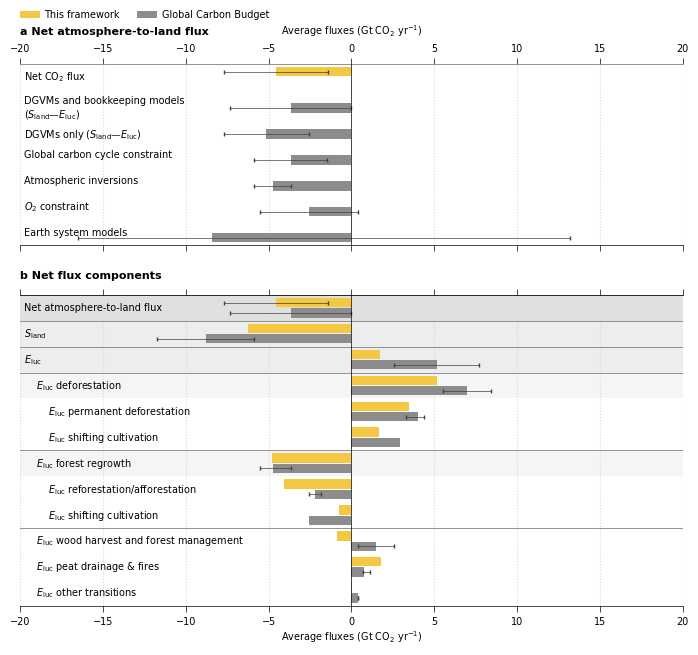

,Label,GCB flux (Gt CO₂ yr⁻¹),LCL flux (Gt CO₂ yr⁻¹)
0,Net atmosphere-to-land flux,-3.666667,-4.542791
1,$S_\mathrm{land}$,-8.800000,-6.269632
2,$E_\mathrm{luc}$,5.133333,1.726864
3,$E_\mathrm{luc}$ deforestation,6.966667,5.162882
4,$E_\mathrm{luc}$ permanent deforestation,4.033333,3.470042
5,$E_\mathrm{luc}$ shifting cultivation,2.933333,1.646717
6,$E_\mathrm{luc}$ forest regrowth,-4.766667,-4.813577
7,$E_\mathrm{luc}$ reforestation/afforestation,-2.200000,-4.066220
8,$E_\mathrm{luc}$ shifting cultivation,-2.566667,-0.747357
9,$E_\mathrm{luc}$ wood harvest and forest manag...,1.466667,-0.847514


In [16]:
### Global Carbon Budget comparison — two-panel horizontal paired bars that share one x-axis (fixed -20..20, full width). 
###   Panel a: net atmosphere-to-land flux — LCL (shown once) vs. several GCB-derived estimates.
###   Panel b: E_luc / S_land decomposition; GCB hierarchy shown via label indentation + shading.
### Paired bars: yellow = This framework (LCL) on top, grey = Global Carbon Budget below.
### Error whiskers where uncertainty is available (GCB stdev/range real; LCL ±1 on net = placeholder).

EXCEL_PATH = LULUCF_zonal_stats_folder / 'LCL_LULUCF_vs_GCB_land_20260624.xlsx'
GCB_COLOR = '#8C8C8C'   # grey   = Global Carbon Budget
LCL_COLOR = '#F4C842'   # yellow = This framework (LCL)
SHADE_DARK, SHADE_MED, SHADE_LIGHT = '0.88', '0.93', '0.96'   # row-band backgrounds

raw = pd.read_excel(EXCEL_PATH, sheet_name='comparison', header=0)
raw = raw.iloc[:, [1, 4, 5, 12, 13, 16]].copy()
raw.columns = ['gcb_label', 'gcb_flux', 'gcb_stdev', 'lcl_label', 'lcl_flux', 'lcl_stdev']

def parse_stdev(val, central=None):
    """(lower, upper) distance from the central value, parsing a plain stdev or a
    '[lo, hi]' range; NaNs for 'N/A'/missing."""
    if pd.isna(val):
        return np.nan, np.nan
    s = str(val).strip()
    if s.upper() == 'N/A':
        return np.nan, np.nan
    m = re.match(r'\[\s*([+-]?\d*\.?\d+)\s*,\s*([+-]?\d*\.?\d+)\s*\]', s)
    if m:
        lo, hi = float(m.group(1)), float(m.group(2))
        if central is not None:
            return abs(float(central) - lo), abs(hi - float(central))
        return np.nan, np.nan
    try:
        v = float(s)
        return abs(v), abs(v)
    except ValueError:
        return np.nan, np.nan

# ── Row definitions: (iloc into raw, display label, indent level, bold?, show LCL bar?) ──
PANEL_A = [
    (0,  'Net CO$_2$ flux', 0, False, True,  False),   # LCL bar 
    (0,  '\nDGVMs and bookkeeping models \n($S_\\mathrm{land}$\u2014$E_\\mathrm{luc}$)', 0, False, False, True),    # GCB bar
    (1,  '\nDGVMs only ($S_\\mathrm{land}$\u2014$E_\\mathrm{luc}$)',         0, False, False),
    (2,  'Global carbon cycle constraint',      0, False, False),
    (3,  'Atmospheric inversions',              0, False, False),
    (5,  '$O_2$ constraint',                    0, False, False),
    (6,  'Earth system models',                 0, False, False),
]
PANEL_B = [
    (0,  'Net atmosphere-to-land flux',                     0, False, True),
    (23, '$S_\\mathrm{land}$',                              0, False, True),
    (9,  '$E_\\mathrm{luc}$',                               0, False, True),
    (12, '$E_\\mathrm{luc}$ deforestation',                 1, False, True),
    (13, '$E_\\mathrm{luc}$ permanent deforestation',       2, False, True),
    (14, '$E_\\mathrm{luc}$ shifting cultivation',          2, False, True),
    (15, '$E_\\mathrm{luc}$ forest regrowth',               1, False, True),
    (16, '$E_\\mathrm{luc}$ reforestation/afforestation',   2, False, True),
    (17, '$E_\\mathrm{luc}$ shifting cultivation',          2, False, True),
    (20, '$E_\\mathrm{luc}$ wood harvest and forest management', 1, False, True),
    (19, '$E_\\mathrm{luc}$ peat drainage & fires',         1, False, True),
    (18, '$E_\\mathrm{luc}$ other transitions',             1, False, True),
]
# Row-band shading {row index: shade} and group-separator boundaries (y between rows)
SHADE_A = {}
SEPS_A  = [-0.5]
SHADE_B = {0: SHADE_DARK, 1: SHADE_MED, 2: SHADE_MED, 3: SHADE_LIGHT, 6: SHADE_LIGHT}
SEPS_B  = [-0.5, 0.5, 1.5, 2.5, 5.5, 8.5]   # incl. line below E_luc (2.5)

XLIM = 20
BW, OFF = 0.36, 0.20          # bar height and the +/- offset that pairs the two bars
LABEL_X0, INDENT_STEP = 0.006, 0.018   # left anchor (axes frac, inside chart) + indent per level
LBL_FS, TICK_FS, TITLE_FS, LEG_FS = 7, 7, 7, 7   # match the other figures' font sizes

def draw_panel(ax, rows, shade, seps):
    n = len(rows)
    for i, c in shade.items():                          # full-width row-band shading
        ax.axhspan(i - 0.5, i + 0.5, color=c, lw=0, zorder=-2)
    for i, row in enumerate(rows):
        idx, label, indent, bold, show_lcl = row[:5]
        show_gcb = row[5] if len(row) > 5 else True
        r = raw.iloc[idx]
        if show_lcl and pd.notna(r['lcl_flux']):       # yellow (LCL) on top
            ax.barh(i - OFF, r['lcl_flux'], height=BW, color=LCL_COLOR, zorder=3)
            lo, hi = parse_stdev(r['lcl_stdev'], r['lcl_flux'])
            if not np.isnan(lo):
                ax.errorbar(r['lcl_flux'], i - OFF, xerr=[[lo], [hi]], fmt='none',
                            ecolor='0.25', capsize=1.5, elinewidth=0.5, zorder=5)
        if show_gcb and pd.notna(r['gcb_flux']):       # grey (GCB) below
            ax.barh(i + OFF, r['gcb_flux'], height=BW, color=GCB_COLOR, zorder=3)
            lo, hi = parse_stdev(r['gcb_stdev'], r['gcb_flux'])
            if not np.isnan(lo):
                ax.errorbar(r['gcb_flux'], i + OFF, xerr=[[lo], [hi]], fmt='none',
                            ecolor='0.25', capsize=1.5, elinewidth=0.5, zorder=5)
        xpos = LABEL_X0 + indent * INDENT_STEP
        if '||' in label:                               # bold main line + non-bold sub line
            main, sub = label.split('||')
            ax.text(xpos, i - 0.18, main, transform=ax.get_yaxis_transform(),
                    ha='left', va='center', fontsize=LBL_FS,
                    fontweight=('bold' if bold else 'normal'), zorder=4)
            ax.text(xpos, i + 0.18, sub, transform=ax.get_yaxis_transform(),
                    ha='left', va='center', fontsize=LBL_FS, fontweight='normal', zorder=4)
        else:
            ax.text(xpos, i, label, transform=ax.get_yaxis_transform(),
                    ha='left', va='center', fontsize=LBL_FS,
                    fontweight=('bold' if bold else 'normal'), zorder=4)
    for y in seps:                                       # thin group separator lines
        ax.axhline(y, color='0.5', linewidth=0.6, zorder=2)
    ax.axvline(0, color='black', linewidth=0.5, zorder=6)
    ax.set_ylim(n - 0.5, -0.5)                           # row 0 at the top
    ax.set_yticks([])

fig, (ax_a, ax_b) = plt.subplots(
    2, 1, figsize=(FIG_W_IN, (14) * FIG_W_IN / 13), sharex=True,
    gridspec_kw={'height_ratios': [len(PANEL_A), len(PANEL_B)]})

draw_panel(ax_a, PANEL_A, SHADE_A, SEPS_A)
draw_panel(ax_b, PANEL_B, SHADE_B, SEPS_B)

for ax in (ax_a, ax_b):
    despine(ax)
    ax.spines['left'].set_visible(False)
    ax.set_xlim(-XLIM, XLIM)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.grid(visible=True, axis='x', color='0.85', linestyle=':', linewidth=0.8)
    ax.set_axisbelow(True)

# x tick numbers at the top of panel a and the bottom of panel b
ax_a.tick_params(axis='x', top=True, labeltop=True, bottom=True, labelbottom=False,
                 labelsize=TICK_FS, length=4)
ax_a.spines['bottom'].set_visible(True)
ax_a.spines['bottom'].set_zorder(3)
ax_b.tick_params(axis='x', bottom=True, labelbottom=True, top=True, labeltop=False,
                 labelsize=TICK_FS, length=4)
ax_b.spines['top'].set_visible(True)
ax_b.spines['top'].set_zorder(3)

# flat one-row legend on top, aligned to the left of the layout (house-style legend_top)
legend_top(ax_a, [(mpatches.Patch(facecolor=LCL_COLOR), 'This framework'),
                  (mpatches.Patch(facecolor=GCB_COLOR), 'Global Carbon Budget')],
           x=0.0, base_pt=32, fontsize=LEG_FS)

# 'Average fluxes' axis title (units inline), centred on the zero line: above a, below b
_TITLE = 'Average fluxes (Gt CO$_2$ yr$^{-1}$)'
ax_a.text(0, 1.14, _TITLE, transform=ax_a.get_xaxis_transform(),
          ha='center', va='bottom', fontsize=TITLE_FS, fontweight='normal')
ax_b.text(0, -0.075, _TITLE, transform=ax_b.get_xaxis_transform(),
          ha='center', va='top', fontsize=TITLE_FS, fontweight='normal')

# panel letters, raised clear of the x-axis numbers
ax_a.annotate('a Net atmosphere-to-land flux', xy=(0.0, 1.0), xycoords='axes fraction',
              xytext=(0, 20), textcoords='offset points',
              fontsize=8, fontweight='bold', va='bottom', ha='left')
ax_b.annotate('b Net flux components', xy=(0.0, 1.0), xycoords='axes fraction',
              xytext=(0, 10), textcoords='offset points',
              fontsize=8, fontweight='bold', va='bottom', ha='left')

fig.subplots_adjust(left=0.05, right=0.985, top=0.80, bottom=0.09, hspace=0.20)
plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_GCB_two_panel_horizontal_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Panel b data table ────────────────────────────────────────────────────
_b_records = []
for idx, label, indent, bold, show_lcl in PANEL_B:
    r = raw.iloc[idx]
    _b_records.append({
        'Label':                    label.replace('\n', ' '),
        'GCB flux (Gt CO₂ yr⁻¹)':  r['gcb_flux']  if pd.notna(r['gcb_flux'])                else None,
        'LCL flux (Gt CO₂ yr⁻¹)':  r['lcl_flux']  if (show_lcl and pd.notna(r['lcl_flux'])) else None,
    })
display(pd.DataFrame(_b_records))


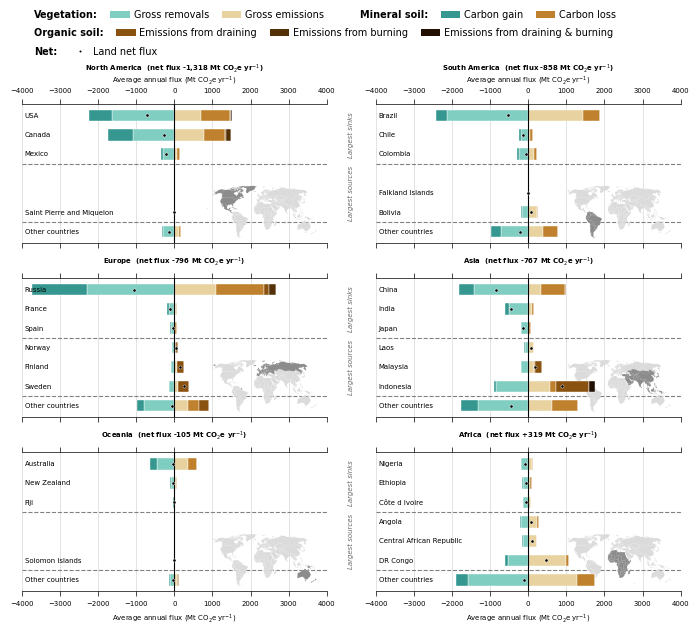

In [18]:
### Bar graphs of countries with largest net sources and sinks by region
### Country-level gross/net LULUCF fluxes by region (horizontal stacked bars, net as dot)
### Top 3 net emitters + top 3 net removers per region + Other countries

# ── Setup ───────────────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()

MIN_SOIL_LOSS = COL_MINERAL_SOIL_LOSS
MIN_SOIL_GAIN = COL_MINERAL_SOIL_GAIN

agg_cols = [COL_VEG_EMIS, COL_VEG_REMOV, MIN_SOIL_LOSS, MIN_SOIL_GAIN, COL_ORGANIC_SOIL_DRAINED, COL_ORGANIC_SOIL_BURNED, COL_ORGANIC_SOIL_DRAINED_BURNED, COL_LULUCF_NET]
df_wide = (df.groupby(["region_L1", "country_name"], as_index=False)[agg_cols].sum())
for col in agg_cols:
    df_wide[col] = df_wide[col] / n_years / 1e6   # Mg -> Mt annual average

df_wide["gross_emis_Mt"]     = df_wide[COL_VEG_EMIS] + df_wide[[COL_ORGANIC_SOIL_DRAINED, COL_ORGANIC_SOIL_BURNED, COL_ORGANIC_SOIL_DRAINED_BURNED]].sum(axis=1) + df_wide[MIN_SOIL_LOSS]
df_wide["gross_remov_Mt"]    = df_wide[COL_VEG_REMOV]
df_wide["min_soil_remov_Mt"] = df_wide[MIN_SOIL_GAIN]
df_wide["net_Mt"]            = df_wide[COL_LULUCF_NET]

REGIONS_TO_DROP = {"Antarctica", "Unassigned", "unassigned"}
df_wide = df_wide[~df_wide["region_L1"].isin(REGIONS_TO_DROP)].copy()

def select_countries(group, region_name):
    # Fixed 7-row panel: [Other, 3 sources, 3 sinks]. Missing slots stay blank.
    sinks   = group[group["net_Mt"] < 0].nsmallest(3, "net_Mt")
    rest    = group[~group["country_name"].isin(sinks["country_name"])]
    sources = rest[rest["net_Mt"] > 0].nlargest(3, "net_Mt")
    others  = rest[~rest["country_name"].isin(sources["country_name"])]

    def _blank():
        b = pd.Series({c: np.nan for c in group.columns}, dtype=object)
        b["country_name"]   = ""
        b["region_L1"]          = region_name
        b["featured_group"] = "empty"
        return b

    def _slot(frame, tag):
        out = []
        for _, r in frame.sort_values("net_Mt", ascending=False).iterrows():
            r = r.copy(); r["region_L1"] = region_name; r["featured_group"] = tag; out.append(r)
        while len(out) < 3:
            out.append(_blank())
        return out

    if len(others) > 0:
        o = group[group["country_name"].isin(others["country_name"])].sum(numeric_only=True)
        o["country_name"]   = "Other countries"
        o["region_L1"]          = region_name
        o["featured_group"] = "other"
        other_row = o
    else:
        other_row = _blank()

    rows = [other_row] + _slot(sources, "source") + _slot(sinks, "sink")
    return pd.DataFrame(rows).reset_index(drop=True)

df_plot = (
    df_wide.groupby("region_L1", group_keys=False)
    .apply(lambda grp: select_countries(grp, grp.name), include_groups=False)
    .reset_index(drop=True)
)

# ── Colours ──────────────────────────────────────────────────────────────────
COLOR_VEG_EMIS  = "#e8d3a0"
COLOR_ORG_DRAINED        = "#8a5210"
COLOR_ORG_BURNED         = "#553107"
COLOR_ORG_DRAINED_BURNED = "#210f01"
COLOR_MIN_EMIS  = "#bf812d"
COLOR_VEG_REMOV = "#80CDC1"
COLOR_MIN_REMOV = "#35978F"
DOT_COLOR       = "black"
DOT_SIZE        = 5

emis_max  = (df_plot[COL_VEG_EMIS] + df_plot[[COL_ORGANIC_SOIL_DRAINED, COL_ORGANIC_SOIL_BURNED, COL_ORGANIC_SOIL_DRAINED_BURNED]].sum(axis=1) + df_plot[MIN_SOIL_LOSS]).max()
remov_max = (df_plot["gross_remov_Mt"] + df_plot["min_soil_remov_Mt"]).abs().max()
axis_max  = int(np.ceil(max(emis_max, remov_max) / 1000) * 1000)
X_TICKS   = list(range(-axis_max, axis_max + 1, 1000))
_unit   = "Mt CO$_2$e yr$^{-1}$"
_xlabel = f"Average annual flux ({_unit})"

# ── Region net flux, used for the titles and to sort the panels ───────────────
region_net = df_wide.groupby("region_L1")["net_Mt"].sum()
regions    = region_net.sort_values(ascending=True).index.tolist()    # lowest net flux -> highest
n_regions  = len(regions)
ncols = 2                              # panels per row (layout knob)
nrows = int(np.ceil(n_regions / ncols))

# Region locator map (Robinson) drawn behind the bars
_iso2region = df.drop_duplicates("adm0").set_index("adm0")["region_L1"]
world = load_world_robinson().copy()
world["_region"] = world["iso_a3"].map(_iso2region)

fig, axes = plt.subplots(nrows, ncols, figsize=(FIG_W_IN, (nrows * 4.3) * FIG_W_IN / 15), squeeze=False, dpi=100)

xlim  = (-axis_max, axis_max)   # start/end exactly on the last gridline
_row_mids = {}

for idx, region in enumerate(regions):
    row, col = idx // ncols, idx % ncols
    ax = axes[row][col]

    df_r      = df_plot[df_plot["region_L1"] == region].reset_index(drop=True)  # fixed 7 rows: [Other, 3 sources, 3 sinks]

    countries = df_r["country_name"].tolist()
    y = np.arange(len(countries))
    veg_e=df_r[COL_VEG_EMIS].values; min_loss=df_r[MIN_SOIL_LOSS].values
    org_dr=df_r[COL_ORGANIC_SOIL_DRAINED].values; org_bu=df_r[COL_ORGANIC_SOIL_BURNED].values; org_db=df_r[COL_ORGANIC_SOIL_DRAINED_BURNED].values
    veg_r=df_r["gross_remov_Mt"].values; min_gain=df_r["min_soil_remov_Mt"].values

    ax.barh(y, veg_e,                          height=0.6, color=COLOR_VEG_EMIS, edgecolor="white", linewidth=0.3)
    ax.barh(y, min_loss, left=veg_e,           height=0.6, color=COLOR_MIN_EMIS, edgecolor="white", linewidth=0.3)
    ax.barh(y, org_dr, left=veg_e+min_loss,               height=0.6, color=COLOR_ORG_DRAINED, edgecolor="white", linewidth=0.3)
    ax.barh(y, org_bu, left=veg_e+min_loss+org_dr,        height=0.6, color=COLOR_ORG_BURNED, edgecolor="white", linewidth=0.3)
    ax.barh(y, org_db, left=veg_e+min_loss+org_dr+org_bu, height=0.6, color=COLOR_ORG_DRAINED_BURNED, edgecolor="white", linewidth=0.3)
    ax.barh(y, veg_r,                      height=0.6, color=COLOR_VEG_REMOV, edgecolor="white", linewidth=0.3)
    ax.barh(y, min_gain, left=veg_r,       height=0.6, color=COLOR_MIN_REMOV, edgecolor="white", linewidth=0.3)
    ax.scatter(df_r["net_Mt"].values, y, color=DOT_COLOR, zorder=5, s=DOT_SIZE, edgecolors="white", linewidths=0.3)

    ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, zorder=0.67)   # Other | sources (behind map)
    ax.axhline(y=3.5, color="gray", linestyle="--", linewidth=0.8, zorder=0.67)   # sources | sinks (behind map)
    ax.set_ylim(-0.6, 6.6)
    if col == 0:
        _row_mids[row] = (2.0, 5.0, ax)

    ax.set_yticks(y); ax.set_yticklabels([]); ax.tick_params(axis="y", left=False, right=False)
    x_label = xlim[0] + (xlim[1] - xlim[0]) * 0.01
    for yi, name in zip(y, countries):
        if name:
            ax.text(x_label, yi, name, ha="left", va="center", fontsize=5, clip_on=True)
    ax.set_xlim(xlim); ax.set_xticks(X_TICKS)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(axis="x", linewidth=0.5, alpha=0.5, which="major"); ax.set_axisbelow(True)

    # No side spines; x-axis line + tick marks on BOTH top and bottom of every panel
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.tick_params(axis="x", top=True, bottom=True, labeltop=False, labelbottom=False, labelsize=5)
    # Number labels + axis title only where they were: first-row top, last-row bottom
    if row == 0:
        ax.xaxis.set_label_position("top")
        ax.tick_params(axis="x", labeltop=True)
        ax.set_xlabel(_xlabel, fontsize=5)
        title_pad = 24
    else:
        ax.set_xlabel(None)
        title_pad = 10
    if row == nrows - 1:
        ax.xaxis.set_label_position("bottom")
        ax.tick_params(axis="x", labelbottom=True)
        ax.set_xlabel(_xlabel, fontsize=5)

    ax.set_title(f"{region}  (net flux {region_net[region]:+,.0f} {_unit})",
                 fontsize=5, fontweight="bold", pad=title_pad)

for idx in range(n_regions, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

# Wider gaps between rows and columns
fig.subplots_adjust(left=0.035, right=0.965, top=0.85, bottom=0.05, hspace=0.25, wspace=0.16)

fig.canvas.draw()
for _i, _region in enumerate(regions):
    region_inset_map(axes[_i // ncols][_i % ncols], world, world["_region"] == _region)

# ── Legend on top (grouped, two rows), same format as the other figures ───────
_dot = Line2D([], [], marker="o", linestyle="", color=DOT_COLOR, markersize=2.24, markeredgecolor="white", markeredgewidth=0.8)
_row_top = [
    ("Vegetation:",   [(Patch(facecolor=COLOR_VEG_REMOV), "Gross removals"),
                       (Patch(facecolor=COLOR_VEG_EMIS),  "Gross emissions")]),
    ("Mineral soil:", [(Patch(facecolor=COLOR_MIN_REMOV), "Carbon gain"),
                       (Patch(facecolor=COLOR_MIN_EMIS),  "Carbon loss")]),
]
_row_bot = [
    ("Organic soil:", [(Patch(facecolor=COLOR_ORG_DRAINED),        "Emissions from draining"),
                       (Patch(facecolor=COLOR_ORG_BURNED),         "Emissions from burning"),
                       (Patch(facecolor=COLOR_ORG_DRAINED_BURNED), "Emissions from draining & burning")]),
    ("Net:",          [(_dot, "Land net flux")]),
]
grouped_legend_top(axes[0][0], _row_top + _row_bot, x=0.04, fontsize=7, single_line=True, base_pt=34, align_text_left=True)

# ── "Largest sources / sinks" gutter labels ──────────────────────────────────
fig.canvas.draw()
for _row in range(nrows):
    for _c in range(ncols - 1):                       # one set of labels per column gutter
        axL, axR = axes[_row][_c], axes[_row][_c + 1]
        if not (axL.get_visible() and axR.get_visible()):
            continue
        x_mid = (axL.get_position().x1 + axR.get_position().x0) / 2
        for y_dat, lbl in [(2.0, "Largest sources"), (5.0, "Largest sinks")]:
            _, y_fig = fig.transFigure.inverted().transform(axL.transData.transform([0, y_dat]))
            fig.text(x_mid, y_fig, lbl, ha="center", va="center",
                     fontsize=5, color="dimgray", style="italic", rotation=90)

plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_top_flux_countries_by_region_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

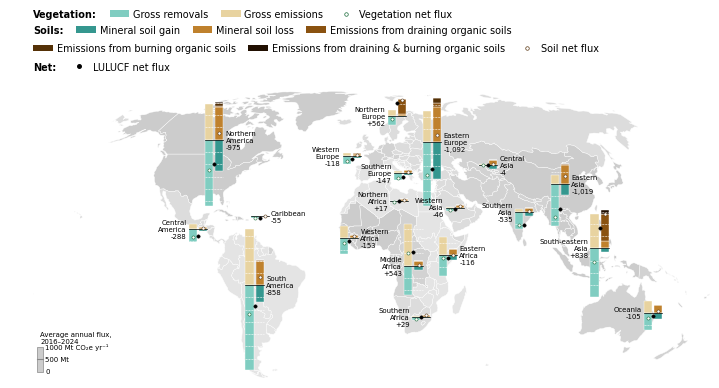

In [19]:
### Pan et al. 2024-style regional map: average annual LULUCF component fluxes by UN geoscheme region
### From Claude sessions 'Pan et al. regional LULUCF flux map' and 'LULUCF and component table creation'

# ── Data prep ────────────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()

COMP_COLS = {
    'veg_gross_emis':   COL_VEG_EMIS,
    'veg_gross_remov':  COL_VEG_REMOV,
    'veg_net':          'veg__net_flux__all_C_pools__all_gases__MgCO2e_yr',
    'mineral_soil_loss': COL_MINERAL_SOIL_LOSS,
    'mineral_soil_gain': COL_MINERAL_SOIL_GAIN,
    'organic_soil_drained':        COL_ORGANIC_SOIL_DRAINED,
    'organic_soil_burned':         COL_ORGANIC_SOIL_BURNED,
    'organic_soil_drained_burned': COL_ORGANIC_SOIL_DRAINED_BURNED,
    'total_LULUCF':     COL_LULUCF_NET,
}

df["map_region"] = np.where(
    df["region_L1"] == "Oceania", "Oceania", df["region_L2_L3"]
)
df = df[
    df["map_region"].notna()
    & ~df["map_region"].isin(["Antarctica", "Unassigned", "unassigned"])
].copy()

regional_wide = (
    df
    .groupby("map_region")[list(COMP_COLS.values())]
    .sum()
    .div(n_years)
    .rename(columns={v: k for k, v in COMP_COLS.items()})
)

# ── Map setup ────────────────────────────────────────────────────────────────
ROBINSON_CRS = cn.Robinson_crs

def _iso_to_map_region(iso):
    if not isinstance(iso, str) or iso == "-99":
        return None
    if cn.iso_to_region_UN_geoscheme_L1.get(iso) == "Oceania":
        return "Oceania"
    return cn.iso_to_region_UN_geoscheme_L2_L3.get(iso)

import os as _os
_ne = "data/ne_110m_admin_0_countries.zip"
_src = _ne if _os.path.exists(_ne) else "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(_src).rename(columns={"ISO_A3_EH": "iso_a3"})

world = world[world["iso_a3"] != "ATA"].copy()
world["map_region"] = world["iso_a3"].map(_iso_to_map_region)

all_regions_sorted = sorted([
    "Northern Africa", "Western Africa", "Middle Africa", "Eastern Africa", "Southern Africa",
    "Northern Europe", "Western Europe", "Southern Europe", "Eastern Europe",
    "Western Asia", "Central Asia", "Southern Asia", "Eastern Asia", "South-eastern Asia",
    "Northern America", "Central America", "Caribbean", "South America", "Oceania",
])
_region_grays = ["#cccccc", "#dcdcdc", "#d2d2d2", "#e4e4e4"]   # light grays so bars stay visible
REGION_COLORS = {region: _region_grays[i % len(_region_grays)] for i, region in enumerate(all_regions_sorted)}

world["map_color"] = world["map_region"].map(lambda r: REGION_COLORS.get(r, "#d9d9d9"))
world = world.to_crs(ROBINSON_CRS)

BAR_POSITIONS_WGS84 = {
    "Northern Africa":    ( 15,  27),
    "Western Africa":     (-12,  10),
    "Middle Africa":      ( 22,  -3),
    "Eastern Africa":     ( 40,   2),
    "Southern Africa":    ( 27, -27),
    "Northern Europe":    ( 18,  68),
    "Western Europe":     (-12,  48),
    "Southern Europe":    ( 18,  40),
    "Eastern Europe":     ( 38,  55),
    "Western Asia":       ( 45,  24),
    "Central Asia":       ( 68,  44),
    "Southern Asia":      ( 82,  22),
    "Eastern Asia":       (105,  35),
    "South-eastern Asia": (120,   5),
    "Northern America":   (-100,  56),
    "Central America":    ( -92,  14),
    "Caribbean":          ( -60,  20),
    "South America":      ( -62, -12),
    "Oceania":            ( 152, -25),
}

_anchor_gdf = gpd.GeoDataFrame(
    {"region": list(BAR_POSITIONS_WGS84.keys())},
    geometry=[Point(lon, lat) for lon, lat in BAR_POSITIONS_WGS84.values()],
    crs="EPSG:4326",
).to_crs(ROBINSON_CRS)

BAR_POSITIONS = {
    row["region"]: (row.geometry.x, row.geometry.y)
    for _, row in _anchor_gdf.iterrows()
}

COMP_COLORS = {
    "veg_gross_emis":    "#e8d3a0",
    "veg_gross_remov":   "#80CDC1",
    "organic_soil_drained":        "#8a5210",
    "organic_soil_burned":         "#553107",
    "organic_soil_drained_burned": "#210f01",
    "mineral_soil_loss": "#bf812d",
    "mineral_soil_gain": "#35978F",
}
VEG_NET_EDGE_COLOR = "#1a6b3a"
MIN_NET_EDGE_COLOR = "#5c3a16"

SUB_HW   = 200_000
HALF_GAP = 50_000

comp_cols_for_scale = ["veg_gross_emis", "veg_gross_remov",
                       "organic_soil_drained", "organic_soil_burned", "organic_soil_drained_burned", "mineral_soil_loss", "mineral_soil_gain"]
max_abs = regional_wide[comp_cols_for_scale].abs().max().max()
SCALE   = 4_200_000 / max_abs

bounds = world.total_bounds
_A = (bounds[2] - bounds[0]) / (bounds[3] - bounds[1])   # Robinson map aspect (~2.36)
MARGIN_IN = 0.16                                          # white border; save180 makes it uniform on all 4 sides
LEGEND_IN = 1.25                                         # band reserved above the map for the legend
_W = FIG_W_IN - 2 * MARGIN_IN                             # render narrower than 180 mm so a margin survives the crop+pad
_map_h_in = _W / _A
fig, ax = plt.subplots(figsize=(_W, _map_h_in + LEGEND_IN))
ax.set_aspect("equal", adjustable="box", anchor="SW")
ax.set_axis_off()
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])
ax.set_position([0.0, 0.0, 1.0, _map_h_in / (_map_h_in + LEGEND_IN)])   # map spans full figure width

world.plot(ax=ax, color=world["map_color"].tolist(), edgecolor="white", linewidth=0.3, zorder=1)

_cx_center = (bounds[0] + bounds[2]) / 2
LABEL_SIDE = {   # per-region override: "left" or "right"
    "Central America": "left", "Western Europe": "left",
    "Eastern Europe": "right", "Central Asia": "right",
    "Eastern Asia": "right", "Eastern Africa": "right",
}

for region, row in regional_wide.iterrows():
    if region not in BAR_POSITIONS:
        continue
    cx, cy = BAR_POSITIONS[region]
    cx_veg  = cx - SUB_HW - HALF_GAP
    cx_soil = cx + SUB_HW + HALF_GAP
    veg_left  = cx_veg  - SUB_HW
    soil_left = cx_soil - SUB_HW

    # ── Vegetation bar (gross emis stacked positive, gross remov negative) ──
    veg_pos_top = veg_neg_bot = 0.0
    for comp in ["veg_gross_emis", "veg_gross_remov"]:
        val = row.get(comp, np.nan)
        if pd.isna(val):
            continue
        h = val * SCALE
        bottom = veg_pos_top if val >= 0 else veg_neg_bot
        if val >= 0: veg_pos_top += h
        else:        veg_neg_bot += h
        ax.add_patch(mpatches.Rectangle(
            (veg_left, cy + bottom), SUB_HW * 2, h,
            facecolor=COMP_COLORS[comp], edgecolor="white", linewidth=0.3, zorder=4,
        ))

    # ── Soil bar: organic + mineral loss stacked positive,
    #              mineral gain stacked negative ────────────────────────────
    soil_pos_top = soil_neg_bot = 0.0
    for comp in ["mineral_soil_loss", "organic_soil_drained", "organic_soil_burned", "organic_soil_drained_burned", "mineral_soil_gain"]:
        val = row.get(comp, np.nan)
        if pd.isna(val):
            continue
        h = val * SCALE
        bottom = soil_pos_top if val >= 0 else soil_neg_bot
        if val >= 0: soil_pos_top += h
        else:        soil_neg_bot += h
        ax.add_patch(mpatches.Rectangle(
            (soil_left, cy + bottom), SUB_HW * 2, h,
            facecolor=COMP_COLORS[comp], edgecolor="white", linewidth=0.3, zorder=4,
        ))

    soil_right = cx_soil + SUB_HW

    # horizontal gridlines (every 500 Mt) behind the bar pair, as wide as the pair
    _gstep = 500e6 * SCALE
    _k = 1
    while _k * _gstep <= max(veg_pos_top, soil_pos_top) + 1:
        ax.plot([veg_left, soil_right], [cy + _k * _gstep, cy + _k * _gstep],
                color="white", linewidth=0.4, linestyle="--", zorder=4.5)
        _k += 1
    _k = 1
    while -_k * _gstep >= min(veg_neg_bot, soil_neg_bot) - 1:
        ax.plot([veg_left, soil_right], [cy - _k * _gstep, cy - _k * _gstep],
                color="white", linewidth=0.4, linestyle="--", zorder=4.5)
        _k += 1

    ax.plot([veg_left, soil_right], [cy, cy], color="black", linewidth=0.5, zorder=5)

    veg_net = row.get("veg_net", np.nan)
    if not pd.isna(veg_net):
        ax.scatter(cx_veg, cy + veg_net * SCALE, s=5, zorder=6,
                   facecolors="white", edgecolors=VEG_NET_EDGE_COLOR, linewidths=0.4)

    _ml = row.get("mineral_soil_loss", np.nan); _mg = row.get("mineral_soil_gain", np.nan)
    _org = np.nansum([row.get("organic_soil_drained", np.nan), row.get("organic_soil_burned", np.nan), row.get("organic_soil_drained_burned", np.nan)])
    if not (pd.isna(_ml) and pd.isna(_mg) and pd.isna(_org)):
        _soil_net = np.nansum([_ml, _mg, _org])   # all-soil net: mineral loss+gain + organic
        ax.scatter(cx_soil, cy + _soil_net * SCALE, s=5, zorder=6,
                   facecolors="white", edgecolors=MIN_NET_EDGE_COLOR, linewidths=0.4)

    lulucf_net = row.get("total_LULUCF", np.nan)
    if not pd.isna(lulucf_net):
        ax.scatter(cx, cy + lulucf_net * SCALE, s=6, color="black", zorder=6)

    overall_neg_bot = min(veg_neg_bot, soil_neg_bot, 0)
    _net_mt = row.get("total_LULUCF", np.nan) / 1e6
    _name = textwrap.fill(region, width=8, break_long_words=False, break_on_hyphens=False)
    _lbl = _name if pd.isna(_net_mt) else f"{_name}\n{_net_mt:+,.0f}"
    _side = LABEL_SIDE.get(region, "left" if cx > _cx_center else "right")
    if _side == "left":
        _lx, _lha = veg_left - 120_000, "right"
    else:
        _lx, _lha = soil_right + 120_000, "left"
    ax.text(_lx, cy, _lbl, ha=_lha, va="center", fontsize=5, zorder=7)

# ── Legend on top (grouped, same style as the other figures) ──────────────────
_veg_net    = Line2D([], [], marker="o", linestyle="", markersize=2.56,
                     markerfacecolor="white", markeredgecolor=VEG_NET_EDGE_COLOR, markeredgewidth=0.5)
_lulucf_net = Line2D([], [], marker="o", linestyle="", markersize=2.56, color="black")
_soil_net   = Line2D([], [], marker="o", linestyle="", markersize=2.56,
                     markerfacecolor="white", markeredgecolor=MIN_NET_EDGE_COLOR, markeredgewidth=0.5)
grouped_legend_top(ax, [
    ("Vegetation:", [(mpatches.Patch(facecolor=COMP_COLORS["veg_gross_remov"]), "Gross removals"),
                     (mpatches.Patch(facecolor=COMP_COLORS["veg_gross_emis"]),  "Gross emissions"),
                     (_veg_net, "Vegetation net flux")]),
], x=0.0, fontsize=7, single_line=True, base_pt=52, align_text_left=True)
grouped_legend_top(ax, [
    ("Soils:", [(mpatches.Patch(facecolor=COMP_COLORS["mineral_soil_gain"]), "Mineral soil gain"),
                (mpatches.Patch(facecolor=COMP_COLORS["mineral_soil_loss"]), "Mineral soil loss"),
                (mpatches.Patch(facecolor=COMP_COLORS["organic_soil_drained"]),        "Emissions from draining organic soils"),
                (mpatches.Patch(facecolor=COMP_COLORS["organic_soil_burned"]),         "Emissions from burning organic soils"),
                (mpatches.Patch(facecolor=COMP_COLORS["organic_soil_drained_burned"]), "Emissions from draining & burning organic soils"),
                (_soil_net, "Soil net flux")]),
    ("Net:",   [(_lulucf_net, "LULUCF net flux")]),
], x=0.0, fontsize=7, single_line=True, base_pt=14, align_text_left=True)

# ── Scale box ────────────────────────────────────────────────────────────────
sb_x  = bounds[0] + 200_000
sb_y  = bounds[1] + 320_000
ref_w = SUB_HW * 1.5
ref_h_500  = 500e6  * SCALE
ref_h_1000 = 1000e6 * SCALE

ax.text(sb_x + ref_w / 2, sb_y + ref_h_1000 + 150_000,
        "Average annual flux, \n2016–2024",
        ha="left", va="bottom", fontsize=5, zorder=8)

ax.add_patch(mpatches.Rectangle(
    (sb_x, sb_y), ref_w, ref_h_1000,
    facecolor="#cccccc", edgecolor="#888888", linewidth=0.5, zorder=7,
))
ax.plot([sb_x, sb_x + ref_w], [sb_y + ref_h_500, sb_y + ref_h_500],
        color="#888888", linewidth=0.8, zorder=8)

tick_x = sb_x + ref_w + 100_000
ax.text(tick_x, sb_y,              "0",                  va="center", fontsize=5, zorder=8)
ax.text(tick_x, sb_y + ref_h_500,  "500 Mt",             va="center", fontsize=5, zorder=8)
ax.text(tick_x, sb_y + ref_h_1000, "1000 Mt CO₂e yr⁻¹", va="center", fontsize=5, zorder=8)

plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_regional_map_flux_bar_graphs_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

### Other figures (not refined at all)

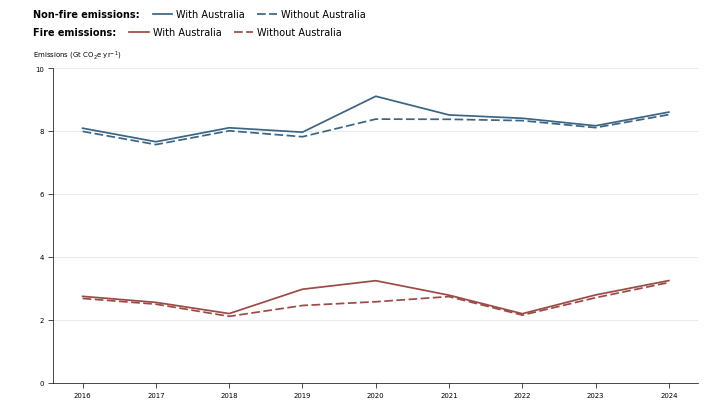

In [20]:
### Global vegetation gross emissions timeseries by fire vs. non-fire, with and without Australia (single panel)
### Per Claude sessions "Create global emissions timeseries graph" and "LULUCF and component table creation"

# ---- Setup ----
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)

def classify_fire(x):
    try:
        return "Fire" if re.search(r"9(0*)$", str(int(float(x)))) else "Non-fire"
    except (ValueError, TypeError):
        return "Non-fire"

df["fire_class"] = df["land_state_node"].apply(classify_fire)

df_with_aus = (
    df.groupby(["fire_class", "year"], as_index=False)[COL_VEG_EMIS]
    .sum().rename(columns={COL_VEG_EMIS: "flux_Mg_CO2e_yr"})
)
df_with_aus["Australia_group"] = "with Australia"

df_without_aus = (
    df[df["country_name"] != "Australia"]
    .groupby(["fire_class", "year"], as_index=False)[COL_VEG_EMIS]
    .sum().rename(columns={COL_VEG_EMIS: "flux_Mg_CO2e_yr"})
)
df_without_aus["Australia_group"] = "without Australia"

df_emis_ts = pd.concat([df_with_aus, df_without_aus], ignore_index=True)
df_emis_ts["value_Gt"] = df_emis_ts["flux_Mg_CO2e_yr"] / 1e9
df_emis_ts["series"]   = df_emis_ts["fire_class"] + " (" + df_emis_ts["Australia_group"] + ")"

# ---- Plot ----
series_order = [
    "Non-fire (with Australia)",
    "Non-fire (without Australia)",
    "Fire (with Australia)",
    "Fire (without Australia)",
]

# Muted, slightly darker blue/red (classier than the default bright primaries)
C_NONFIRE = "#3a6584"
C_FIRE    = "#9c4a45"
series_palette = {
    "Non-fire (with Australia)":    C_NONFIRE,
    "Non-fire (without Australia)": C_NONFIRE,
    "Fire (with Australia)":        C_FIRE,
    "Fire (without Australia)":     C_FIRE,
}
series_dashes = {
    "Non-fire (with Australia)":    "",
    "Non-fire (without Australia)": (5, 2),
    "Fire (with Australia)":        "",
    "Fire (without Australia)":     (5, 2),
}

# 1500 x 900 px at 100 dpi
fig, ax = plt.subplots(figsize=(FIG_W_IN, (9) * FIG_W_IN / 15), dpi=100)
sns.lineplot(
    data=df_emis_ts, x="year", y="value_Gt", ax=ax,
    hue="series", style="series",
    hue_order=series_order, style_order=series_order,
    palette=series_palette, dashes=series_dashes, linewidth=1.25,
)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel(None)
ax.tick_params(axis="y", labelsize=5)
ax.tick_params(axis="x", labelsize=5, pad=3)
if ax.get_legend() is not None:
    ax.get_legend().remove()

# ── Shared styling ────────────────────────────────────────────────────────────
despine(ax)
style_value_axis(ax, 0, df_emis_ts["value_Gt"].max())   # all-positive -> y starts at 0

fig.subplots_adjust(left=0.06, right=0.97, top=0.84, bottom=0.10)
_xL = left_align_x(ax)
horizontal_axis_label(ax, "Emissions (Gt CO$_2$e yr$^{-1}$)", fontsize=5, pad=5, x=_xL)

grouped_legend_top(ax, [
    ("Non-fire emissions:", [(Line2D([], [], color=C_NONFIRE, linewidth=1.25),                       "With Australia"),
                             (Line2D([], [], color=C_NONFIRE, linewidth=1.25, linestyle=(0, (5, 2))), "Without Australia")]),
    ("Fire emissions:",     [(Line2D([], [], color=C_FIRE,    linewidth=1.25),                       "With Australia"),
                             (Line2D([], [], color=C_FIRE,    linewidth=1.25, linestyle=(0, (5, 2))), "Without Australia")]),
], x=_xL, fontsize=7, single_line=False, align_text_left=True, base_pt=22, line_pt=13)

plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/veg_emis_timeseries_fire_status_Australia_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()


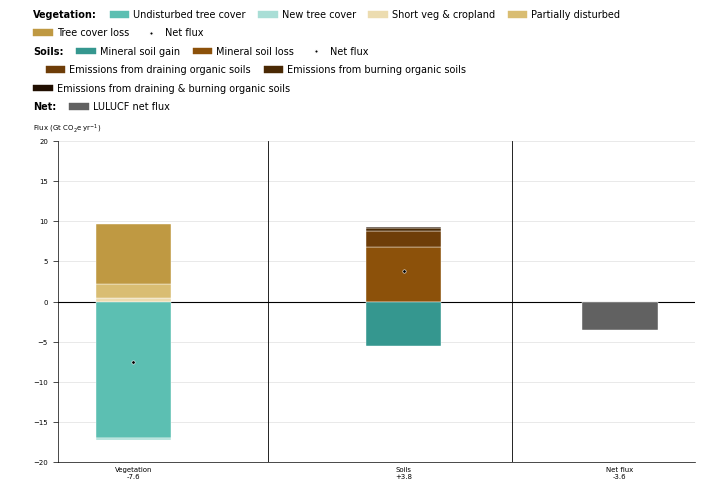

In [22]:
### Average annual fluxes grouped by source: vegetation | soils | net flux
### Duplicate of the emissions/removals/net bar chart, regrouped by component source

# ── Colors (shared with the emissions/removals/net version) ──
C_EMIS_NONTALL  = "#ecdcb0"   # short veg & cropland
C_EMIS_DISTURB  = "#d9bd72"   # partially disturbed tree cover
C_EMIS_LOSS     = "#bf9942"   # tree cover loss
C_MIN_SOIL_LOSS = "#8c510a"   # mineral soil loss
C_ORG_DRAINED        = "#6e3d08"   # organic soil — drained
C_ORG_BURNED         = "#4a2904"   # organic soil — burned
C_ORG_DRAINED_BURNED = "#210f01"   # organic soil — drained & burned
C_REMOV_UNDIST  = "#5cbfb2"   # undisturbed tree cover
C_REMOV_NEW     = "#a9ded6"   # new tree cover
C_MIN_SOIL_GAIN = "#35978F"   # mineral soil gain
C_NET           = "#616161"   # LULUCF net flux

# ── Data aggregation ──────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()
dlc  = df['land_state_detailed_class']
lsbc = df['land_state_broad_class']

def _Gt(mask, col):
    return df.loc[mask, col].sum() / n_years / 1e9

veg_emis_nontall_Gt  = _Gt(lsbc != 'tree',                                                    COL_VEG_EMIS)
veg_emis_disturb_Gt  = _Gt(dlc.isin(['tree_tree_disturbed', 'tree_tree_disturbed_fire_only']), COL_VEG_EMIS)
veg_emis_loss_Gt     = _Gt(dlc == 'tree_loss',                                                COL_VEG_EMIS)
mineral_soil_loss_Gt = df[COL_MINERAL_SOIL_LOSS].sum() / n_years / 1e9
org_drained_Gt       = df[COL_ORGANIC_SOIL_DRAINED].sum()        / n_years / 1e9
org_burned_Gt        = df[COL_ORGANIC_SOIL_BURNED].sum()         / n_years / 1e9
org_db_Gt            = df[COL_ORGANIC_SOIL_DRAINED_BURNED].sum() / n_years / 1e9
org_soil_Gt          = org_drained_Gt + org_burned_Gt + org_db_Gt
veg_remov_undist_Gt  = _Gt(dlc == 'tree_tree_undisturbed', COL_VEG_REMOV)
veg_remov_new_Gt     = _Gt(dlc == 'tree_gain',             COL_VEG_REMOV)
mineral_soil_gain_Gt = df[COL_MINERAL_SOIL_GAIN].sum() / n_years / 1e9
lulucf_net_Gt        = df[COL_LULUCF_NET].sum() / n_years / 1e9

veg_emis_total  = veg_emis_nontall_Gt + veg_emis_disturb_Gt + veg_emis_loss_Gt
veg_remov_total = veg_remov_undist_Gt + veg_remov_new_Gt
soil_emis_total = mineral_soil_loss_Gt + org_soil_Gt
soil_remov_total = mineral_soil_gain_Gt
veg_net  = veg_emis_total + veg_remov_total
soil_net = soil_emis_total + soil_remov_total

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W_IN, (9.5) * FIG_W_IN / 13), dpi=100)
x_veg, x_soil, x_net = 0.0, 2.5, 4.5
bar_w = 0.7

# Vegetation: emissions up, removals down
ax.bar(x_veg, veg_emis_nontall_Gt, width=bar_w, color=C_EMIS_NONTALL, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_veg, veg_emis_disturb_Gt, width=bar_w, color=C_EMIS_DISTURB, bottom=veg_emis_nontall_Gt, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_veg, veg_emis_loss_Gt,    width=bar_w, color=C_EMIS_LOSS,    bottom=veg_emis_nontall_Gt + veg_emis_disturb_Gt, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_veg, veg_remov_undist_Gt, width=bar_w, color=C_REMOV_UNDIST, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_veg, veg_remov_new_Gt,    width=bar_w, color=C_REMOV_NEW,    bottom=veg_remov_undist_Gt, edgecolor="white", linewidth=0.3, zorder=2)

# Soils: emissions up (organic outermost), removals down
ax.bar(x_soil, mineral_soil_loss_Gt, width=bar_w, color=C_MIN_SOIL_LOSS, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_soil, org_drained_Gt, width=bar_w, color=C_ORG_DRAINED, bottom=mineral_soil_loss_Gt, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_soil, org_burned_Gt,  width=bar_w, color=C_ORG_BURNED,  bottom=mineral_soil_loss_Gt + org_drained_Gt, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_soil, org_db_Gt,      width=bar_w, color=C_ORG_DRAINED_BURNED, bottom=mineral_soil_loss_Gt + org_drained_Gt + org_burned_Gt, edgecolor="white", linewidth=0.3, zorder=2)
ax.bar(x_soil, mineral_soil_gain_Gt, width=bar_w, color=C_MIN_SOIL_GAIN, edgecolor="white", linewidth=0.3, zorder=2)

# Net flux
ax.bar(x_net, lulucf_net_Gt, width=bar_w, color=C_NET, edgecolor="white", linewidth=0.3, zorder=2)

# net-flux dots on the vegetation and soils bars
ax.scatter([x_veg, x_soil], [veg_net, soil_net], color="black", s=6, zorder=5,
           edgecolors="white", linewidths=0.4)

ax.axhline(0, color="black", linewidth=0.8, zorder=1)
ax.axvline((x_veg + x_soil) / 2, color="black", linewidth=0.6, zorder=1)
ax.axvline((x_soil + x_net) / 2, color="black", linewidth=0.6, zorder=1)

ax.set_xticks([x_veg, x_soil, x_net])
ax.set_xticklabels([f"Vegetation\n{veg_net:+.1f}", f"Soils\n{soil_net:+.1f}",
                    f"Net flux\n{lulucf_net_Gt:+.1f}"], fontsize=5)
ax.set_xlim(x_veg - bar_w, x_net + bar_w)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", labelsize=5)

# ── Shared styling ────────────────────────────────────────────────────────────
despine(ax)
style_value_axis(ax, min(veg_remov_total, soil_remov_total, lulucf_net_Gt, 0),
                     max(veg_emis_total, soil_emis_total, lulucf_net_Gt, 0))

fig.subplots_adjust(left=0.07, right=0.97, top=0.72, bottom=0.10)
_xL = left_align_x(ax)
horizontal_axis_label(ax, "Flux (Gt CO$_2$e yr$^{-1}$)", fontsize=5, pad=5, x=_xL)
_ndot = dict(marker="o", linestyle="", markersize=2.56, color="black",
             markeredgecolor="white", markeredgewidth=1.0)
grouped_legend_top(ax, [
    ("Vegetation:", [(Patch(color=C_REMOV_UNDIST),  "Undisturbed tree cover"),
                     (Patch(color=C_REMOV_NEW),     "New tree cover"),
                     (Patch(color=C_EMIS_NONTALL),  "Short veg & cropland"),
                     (Patch(color=C_EMIS_DISTURB),  "Partially disturbed"),
                     (Patch(color=C_EMIS_LOSS),     "Tree cover loss"),
                     (Line2D([], [], **_ndot),      "Net flux")]),
    ("Soils:",      [(Patch(color=C_MIN_SOIL_GAIN), "Mineral soil gain"),
                     (Patch(color=C_MIN_SOIL_LOSS), "Mineral soil loss"),
                     (Line2D([], [], **_ndot),      "Net flux")]),
    ("",            [(Patch(color=C_ORG_DRAINED),        "Emissions from draining organic soils"),
                     (Patch(color=C_ORG_BURNED),         "Emissions from burning organic soils"),
                     (Patch(color=C_ORG_DRAINED_BURNED), "Emissions from draining & burning organic soils")]),
    ("Net:",        [(Patch(color=C_NET),           "LULUCF net flux")]),
], x=_xL, fontsize=7, single_line=False, align_text_left=True, base_pt=21, line_pt=13)

plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_avg_annual_fluxes_by_component_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()


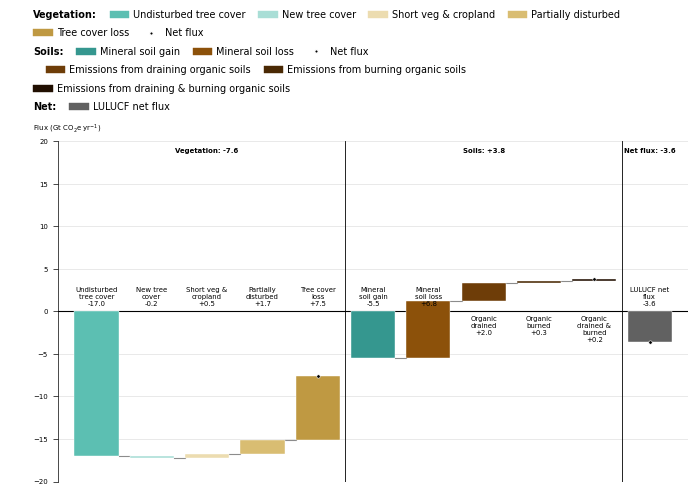

In [23]:
### Average annual fluxes cascade (waterfall) by source: vegetation | soils | net flux
### Each group is a cascade from 0 (removals first, then emissions); per-bar name+value labels

# ── Colors (shared with the grouped-bar version) ──
C_EMIS_NONTALL  = "#ecdcb0"; C_EMIS_DISTURB = "#d9bd72"; C_EMIS_LOSS = "#bf9942"
C_MIN_SOIL_LOSS = "#8c510a"; C_ORG_DRAINED = "#6e3d08"; C_ORG_BURNED = "#4a2904"; C_ORG_DRAINED_BURNED = "#210f01"
C_REMOV_UNDIST  = "#5cbfb2"; C_REMOV_NEW = "#a9ded6"; C_MIN_SOIL_GAIN = "#35978F"
C_NET           = "#616161"

# ── Data aggregation ──────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()
dlc  = df['land_state_detailed_class']
lsbc = df['land_state_broad_class']

def _Gt(mask, col):
    return df.loc[mask, col].sum() / n_years / 1e9

veg_emis_nontall_Gt  = _Gt(lsbc != 'tree',                                                    COL_VEG_EMIS)
veg_emis_disturb_Gt  = _Gt(dlc.isin(['tree_tree_disturbed', 'tree_tree_disturbed_fire_only']), COL_VEG_EMIS)
veg_emis_loss_Gt     = _Gt(dlc == 'tree_loss',                                                COL_VEG_EMIS)
mineral_soil_loss_Gt = df[COL_MINERAL_SOIL_LOSS].sum() / n_years / 1e9
org_drained_Gt       = df[COL_ORGANIC_SOIL_DRAINED].sum()        / n_years / 1e9
org_burned_Gt        = df[COL_ORGANIC_SOIL_BURNED].sum()         / n_years / 1e9
org_db_Gt            = df[COL_ORGANIC_SOIL_DRAINED_BURNED].sum() / n_years / 1e9
org_soil_Gt          = org_drained_Gt + org_burned_Gt + org_db_Gt
veg_remov_undist_Gt  = _Gt(dlc == 'tree_tree_undisturbed', COL_VEG_REMOV)
veg_remov_new_Gt     = _Gt(dlc == 'tree_gain',             COL_VEG_REMOV)
mineral_soil_gain_Gt = df[COL_MINERAL_SOIL_GAIN].sum() / n_years / 1e9
lulucf_net_Gt        = df[COL_LULUCF_NET].sum() / n_years / 1e9

veg_net  = veg_emis_nontall_Gt + veg_emis_disturb_Gt + veg_emis_loss_Gt + veg_remov_undist_Gt + veg_remov_new_Gt
soil_net = mineral_soil_loss_Gt + org_soil_Gt + mineral_soil_gain_Gt

_groups = [
    ("Vegetation", veg_net, [
        (veg_remov_undist_Gt, C_REMOV_UNDIST, "Undisturbed tree cover"),
        (veg_remov_new_Gt,    C_REMOV_NEW,    "New tree cover"),
        (veg_emis_nontall_Gt, C_EMIS_NONTALL, "Short veg & cropland"),
        (veg_emis_disturb_Gt, C_EMIS_DISTURB, "Partially disturbed"),
        (veg_emis_loss_Gt,    C_EMIS_LOSS,    "Tree cover loss")]),
    ("Soils", soil_net, [
        (mineral_soil_gain_Gt, C_MIN_SOIL_GAIN, "Mineral soil gain"),
        (mineral_soil_loss_Gt, C_MIN_SOIL_LOSS, "Mineral soil loss"),
        (org_drained_Gt, C_ORG_DRAINED,        "Organic drained"),
        (org_burned_Gt,  C_ORG_BURNED,         "Organic burned"),
        (org_db_Gt,      C_ORG_DRAINED_BURNED, "Organic drained & burned")]),
    ("Net flux", lulucf_net_Gt, [
        (lulucf_net_Gt,        C_NET,           "LULUCF net flux")]),
]

fig, ax = plt.subplots(figsize=(FIG_W_IN, (10.5) * FIG_W_IN / 14), dpi=100)
bar_w = 0.8
x = 0.0
_off = 0.5
_levels, _maxx, _glabels, _dividers = [0.0], 0.0, [], []
for gname, gnet, comps in _groups:
    x0 = x; running, prev_x = 0.0, None
    for j, (val, color, name) in enumerate(comps):
        if j > 0:
            ax.plot([prev_x + bar_w / 2, x - bar_w / 2], [running, running],
                    color="0.55", linewidth=0.8, zorder=1)
        top = running + val
        ax.bar(x, abs(val), width=bar_w, bottom=min(running, top), color=color, edgecolor="white", linewidth=0.3, zorder=2)
        _nm = textwrap.fill(name, width=11)
        if (running + top) / 2 <= 0:                 # bar below 0 -> label above the 0 line
            ax.text(x, _off, f"{_nm}\n{val:+.1f}", ha="center", va="bottom", fontsize=5, zorder=6)
        else:                                        # bar above 0 -> label below the 0 line
            ax.text(x, -_off, f"{_nm}\n{val:+.1f}", ha="center", va="top", fontsize=5, zorder=6)
        running = top; _levels.append(running)
        prev_x = x; _maxx = x; x += 1
    ax.scatter(x - 1, gnet, color="black", s=6, zorder=5, edgecolors="white", linewidths=0.4)
    _glabels.append(((x0 + x - 1) / 2, gname, gnet))
    _dividers.append(x - 0.5)

ax.axhline(0, color="black", linewidth=0.8, zorder=1)
for _d in _dividers[:-1]:
    ax.axvline(_d, color="black", linewidth=0.6, zorder=1)

# per-bar name + value labels by the x axis
ax.set_xticks([])
ax.set_xlim(-0.7, _maxx + 0.7)
ax.tick_params(axis="y", labelsize=5)

# ── Shared styling ────────────────────────────────────────────────────────────
despine(ax)
ax.spines["bottom"].set_visible(False)
style_value_axis(ax, min(_levels), max(_levels))

# group name + total as a header above each group
for _c, _gn, _gt in _glabels:
    ax.text(_c, 0.98, f"{_gn}: {_gt:+.1f}", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontweight="bold", fontsize=5, zorder=7)

fig.subplots_adjust(left=0.06, right=0.95, top=0.74, bottom=0.10)
_xL = left_align_x(ax)
horizontal_axis_label(ax, "Flux (Gt CO$_2$e yr$^{-1}$)", fontsize=5, pad=5, x=_xL)
_ndot = dict(marker="o", linestyle="", markersize=2.56, color="black",
             markeredgecolor="white", markeredgewidth=1.0)
grouped_legend_top(ax, [
    ("Vegetation:", [(Patch(color=C_REMOV_UNDIST),  "Undisturbed tree cover"),
                     (Patch(color=C_REMOV_NEW),     "New tree cover"),
                     (Patch(color=C_EMIS_NONTALL),  "Short veg & cropland"),
                     (Patch(color=C_EMIS_DISTURB),  "Partially disturbed"),
                     (Patch(color=C_EMIS_LOSS),     "Tree cover loss"),
                     (Line2D([], [], **_ndot),      "Net flux")]),
    ("Soils:",      [(Patch(color=C_MIN_SOIL_GAIN), "Mineral soil gain"),
                     (Patch(color=C_MIN_SOIL_LOSS), "Mineral soil loss"),
                     (Line2D([], [], **_ndot),      "Net flux")]),
    ("",            [(Patch(color=C_ORG_DRAINED),        "Emissions from draining organic soils"),
                     (Patch(color=C_ORG_BURNED),         "Emissions from burning organic soils"),
                     (Patch(color=C_ORG_DRAINED_BURNED), "Emissions from draining & burning organic soils")]),
    ("Net:",        [(Patch(color=C_NET),           "LULUCF net flux")]),
], x=_xL, fontsize=7, single_line=False, align_text_left=True, base_pt=21, line_pt=13)

plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_waterfall_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()


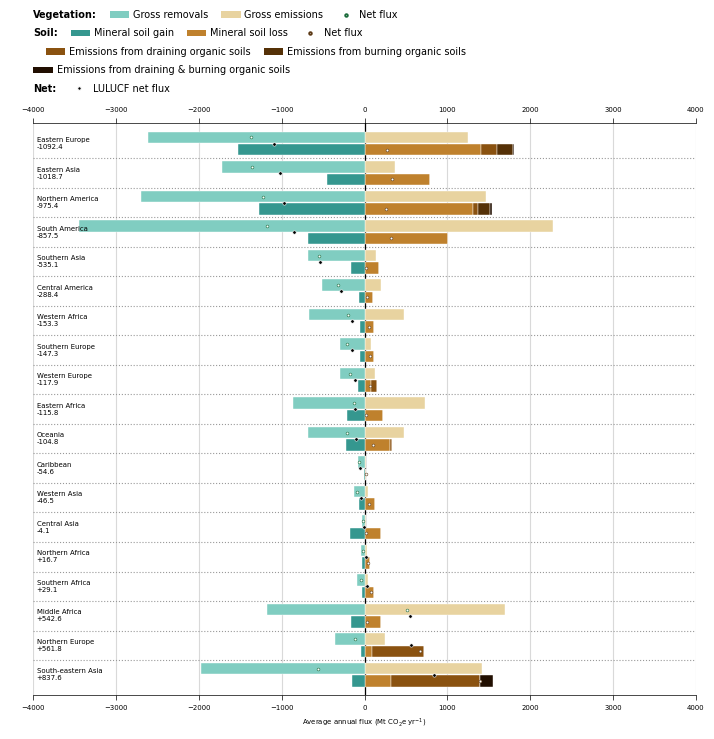

In [24]:
### Regional LULUCF flux: all bar pairs in one horizontal chart, sorted by net flux
### Same data/markers as the Pan et al. regional map, but laid out as a single sorted chart

# ── Data prep (same regions as the regional map) ──────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()

COMP_COLS = {
    'veg_gross_emis':   COL_VEG_EMIS,
    'veg_gross_remov':  COL_VEG_REMOV,
    'veg_net':          'veg__net_flux__all_C_pools__all_gases__MgCO2e_yr',
    'mineral_soil_loss': COL_MINERAL_SOIL_LOSS,
    'mineral_soil_gain': COL_MINERAL_SOIL_GAIN,
    'organic_soil_drained':        COL_ORGANIC_SOIL_DRAINED,
    'organic_soil_burned':         COL_ORGANIC_SOIL_BURNED,
    'organic_soil_drained_burned': COL_ORGANIC_SOIL_DRAINED_BURNED,
    'total_LULUCF':     COL_LULUCF_NET,
}
df["map_region"] = np.where(df["region_L1"] == "Oceania", "Oceania", df["region_L2_L3"])
df = df[df["map_region"].notna() & ~df["map_region"].isin(["Antarctica", "Unassigned", "unassigned"])].copy()

regional = (df.groupby("map_region")[list(COMP_COLS.values())].sum()
            .div(n_years).div(1e6).rename(columns={v: k for k, v in COMP_COLS.items()}))   # Mt CO2e/yr
regions_sorted = regional.sort_values("total_LULUCF", ascending=True).index.tolist()   # negative -> positive

# ── Colours (shared with the regional map) ────────────────────────────────────
C_VEG_EMIS  = "#e8d3a0"; C_VEG_REMOV = "#80CDC1"
C_ORG_DRAINED = "#8a5210"; C_ORG_BURNED = "#553107"; C_ORG_DRAINED_BURNED = "#210f01"
C_MIN_LOSS  = "#bf812d"; C_MIN_GAIN = "#35978F"
VEG_NET_EDGE = "#1a6b3a"; MIN_NET_EDGE = "#5c3a16"

# ── Chart (horizontal paired bars; veg on top, soil below, per region) ────────
fig, ax = plt.subplots(figsize=(FIG_W_IN, (14) * FIG_W_IN / 13), dpi=100)
n = len(regions_sorted)
yy = {region: (n - 1 - i) for i, region in enumerate(regions_sorted)}   # most negative at top
off, bh = 0.21, 0.38

for region in regions_sorted:
    r = regional.loc[region]; y = yy[region]
    # Vegetation bar (y+off): emissions right, removals left
    ax.barh(y + off, r["veg_gross_emis"],  height=bh, color=C_VEG_EMIS,  edgecolor="white", linewidth=0.3, zorder=2)
    ax.barh(y + off, r["veg_gross_remov"], height=bh, color=C_VEG_REMOV, edgecolor="white", linewidth=0.3, zorder=2)
    # Soil bar (y-off): mineral loss + organic right (organic outer), mineral gain left
    ax.barh(y - off, r["mineral_soil_loss"], height=bh, color=C_MIN_LOSS, edgecolor="white", linewidth=0.3, zorder=2)
    ax.barh(y - off, r["organic_soil_drained"], left=r["mineral_soil_loss"], height=bh, color=C_ORG_DRAINED, edgecolor="white", linewidth=0.3, zorder=2)
    ax.barh(y - off, r["organic_soil_burned"], left=r["mineral_soil_loss"] + r["organic_soil_drained"], height=bh, color=C_ORG_BURNED, edgecolor="white", linewidth=0.3, zorder=2)
    ax.barh(y - off, r["organic_soil_drained_burned"], left=r["mineral_soil_loss"] + r["organic_soil_drained"] + r["organic_soil_burned"], height=bh, color=C_ORG_DRAINED_BURNED, edgecolor="white", linewidth=0.3, zorder=2)
    ax.barh(y - off, r["mineral_soil_gain"], height=bh, color=C_MIN_GAIN, edgecolor="white", linewidth=0.3, zorder=2)
    # net markers
    ax.scatter(r["veg_net"], y + off, s=4, zorder=5, facecolors="white", edgecolors=VEG_NET_EDGE, linewidths=0.4)
    ax.scatter(r["mineral_soil_loss"] + r["mineral_soil_gain"] + r["organic_soil_drained"] + r["organic_soil_burned"] + r["organic_soil_drained_burned"], y - off, s=4, zorder=5,
               facecolors="white", edgecolors=MIN_NET_EDGE, linewidths=0.4)
    ax.scatter(r["total_LULUCF"], y, s=6, color="black", zorder=6, edgecolors="white", linewidths=0.4)

ax.axvline(0, color="black", linewidth=0.9, zorder=1)
for _k in range(n - 1):
    ax.axhline(_k + 0.5, color="0.6", linestyle=":", linewidth=0.8, zorder=1)
ax.set_yticks([])
for reg in regions_sorted:                       # region labels printed inside the chart, left-aligned
    ax.text(0.005, yy[reg], f"{reg}\n{regional.loc[reg, 'total_LULUCF']:+.1f}",
            transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=5, zorder=7)
ax.set_ylim(-0.7, n - 0.3)
ax.tick_params(axis="x", top=True, labeltop=True, labelsize=5)

# ── Shared styling ────────────────────────────────────────────────────────────
despine(ax)
ax.spines["top"].set_visible(True)   # x-axis at the top too
ax.spines["left"].set_visible(False)   # no left axis line (labels printed inside)
_dmax = max((regional["veg_gross_emis"]).max(),
            (regional["mineral_soil_loss"] + regional[["organic_soil_drained", "organic_soil_burned", "organic_soil_drained_burned"]].sum(axis=1)).max())
_dmin = min((regional["veg_gross_remov"]).min(), (regional["mineral_soil_gain"]).min())
style_value_axis(ax, _dmin, _dmax, which="x")
ax.grid(visible=True, axis="x", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("Average annual flux (Mt CO$_2$e yr$^{-1}$)", fontsize=5)

fig.subplots_adjust(left=0.05, right=0.985, top=0.82, bottom=0.07)
_vdot = dict(marker="o", linestyle="", markersize=1.92, markerfacecolor="white", markeredgewidth=1.3)
grouped_legend_top(ax, [
    ("Vegetation:", [(Patch(facecolor=C_VEG_REMOV), "Gross removals"),
                     (Patch(facecolor=C_VEG_EMIS),  "Gross emissions"),
                     (Line2D([], [], markeredgecolor=VEG_NET_EDGE, **_vdot), "Net flux")]),
    ("Soil:",       [(Patch(facecolor=C_MIN_GAIN),  "Mineral soil gain"),
                     (Patch(facecolor=C_MIN_LOSS),  "Mineral soil loss"),
                     (Line2D([], [], markeredgecolor=MIN_NET_EDGE, **_vdot), "Net flux")]),
    ("",            [(Patch(facecolor=C_ORG_DRAINED),        "Emissions from draining organic soils"),
                     (Patch(facecolor=C_ORG_BURNED),         "Emissions from burning organic soils"),
                     (Patch(facecolor=C_ORG_DRAINED_BURNED), "Emissions from draining & burning organic soils")]),
    ("Net:",        [(Line2D([], [], marker="o", linestyle="", markersize=2.56, color="black",
                             markeredgecolor="white", markeredgewidth=0.8), "LULUCF net flux")]),
], x=0.0, fontsize=7, single_line=False, base_pt=21, line_pt=11, align_text_left=True)

plt.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_regional_bar_graphs_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()
